# BAM-torch 튜토리얼
---
이 노트북은 모듈식 PyTorch 프레임워크로 원자간 퍼텐셜(interatomic potential)을 만들고 학습시키는 과정을 단계별로 안내합니다.

### 하드웨어 설정
학습 시간을 현실적인 수준으로 유지하려면 이 튜토리얼에서는 **GPU 사용을 권장합니다**.

**Google Colab 사용자:**
1. `Runtime` → `Change runtime type`으로 이동합니다.
2. 하드웨어 가속기 드롭다운에서 **T4 GPU**를 선택합니다.
3. `Save`를 클릭합니다.

CPU에서도 실행할 수 있지만 실행 시간이 상당히 길어집니다. CPU를 쓴다면 설정에서 device 값을 바꿔주세요.
```python
'device': 'cpu'  # instead of 'cuda'
```

### 런타임 문제 해결
Colab 세션은 실행 도중 연결이 끊기거나 멈추는 경우가 있습니다. 그럴 때는:
- **간단한 해결:** 멈춘 셀부터 다시 실행합니다.
- **새로 시작:** `Runtime` → `Disconnect and delete runtime`으로 런타임을 지운 뒤 처음부터 다시 실행합니다.

## 설치 안내

BAM-torch는 **Python 3.11 이상**과 **PyTorch 2.5.1 이상**이 필요합니다.

## 더 알아보기

기술적인 세부 내용과 소스 코드는 아래에서 확인하세요.
- 📄 [Research Paper](https://www.nature.com/articles/s41524-026-02258-9)
- 💻 [GitHub Repository](https://github.com/myung-group/BAM-torch)

---

In [ ]:
%cd /content
!git clone https://github.com/myung-group/BAM-torch
%cd BAM-torch
!pip install -e .
!pip install -e ".[oeq]"

/content
Cloning into 'BAM-torch'...
remote: Enumerating objects: 1868, done.
remote: Counting objects: 100% (452/452), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 1868 (delta 362), reused 326 (delta 311), pack-reused 1416 (from 2)
Receiving objects: 100% (1868/1868), 359.22 MiB | 23.16 MiB/s, done.
Resolving deltas: 100% (1072/1072), done.
Updating files: 100% (196/196), done.
/content/BAM-torch
Obtaining file:///content/BAM-torch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
# %cd /content
# !curl -fL https://codeload.github.com/myung-group/BAM-torch/tar.gz/refs/heads/main -o bam.tar.gz
# !tar xzf bam.tar.gz && mv BAM-torch-main BAM-torch
# %cd /content/BAM-torch
# !pip install -e .
# !pip install -e ".[oeq]"

# 모델 훈련

<h3>모델 훈련에 필요한 파일</h3>
<pre>examples/tutorial/example-3BPA_300K/
|-- main.py
`-- input.json

examples/dataset/
`-- train_300K.xyz</pre>

BAM 모델을 훈련하려면 input.json 파일에서 설정을 구성해야합니다.

### 데이터 세트 설정

fname_traj를 사용하여 훈련 데이터를 지정하고 훈련 및 검증에 사용할 구조 수를 수동으로 정의하십시오.

```json
{
"fname_traj": "train_300K.xyz",
"ntrain": 450,
"nvalid": 50
}
```

- fname_traj: 훈련 파일의 경로
- ntrain: 훈련을 위한 구조의 수 또는 파일 이름이 제공되는 경우 해당 파일에 포함된 전체 데이터 세트입니다.
- nvalid: 유효성 검사를 위한 구조의 수 또는 파일 이름이 제공되는 경우 해당 파일에 포함된 전체 데이터 세트입니다.

### 훈련 모드

`main.py`를 실행하기 전에 예제의 `input.json` 파일에서 `device` 및 `gpu-parallel`를 설정합니다.

#### 단일 GPU

`input.json`에서 다음을 설정합니다.

```json
{
  "device": "gpu",
  "gpu-parallel": false
}
```

그런 다음 GPU 하나로 실행합니다.

```bash
CUDA_VISIBLE_DEVICES=0 python main.py
```

#### 다중 GPU

```json
{
  "device": "gpu",
  "gpu-parallel": true
}
```

그런 다음 GPU를 노출하여 `main.py`를 사용하고 실행합니다.

```bash
CUDA_VISIBLE_DEVICES=0,1,2,3 python main.py
```

### 손실 함수

 `input.json` 파일에서 손실 함수와 상대 가중치를 구성합니다.

```json
{
"NN": {
"loss_config": {
"energy_loss": "mse",
"force_loss": "mse"
},
"enr_lambda": 1,
"frc_lambda": 100
}
}
```


사용 가능한 손실 유형:

- `"mse"`: 평균 제곱 오차
- `"mae"` 또는 `"l1"`: 평균 절대 오치
- `"rmse"`: 평균 제곱근 오차

`enr_lambda` 및 `frc_lambda`를 사용하여 에너지 및 힘 손실의 상대적 가중치를 제어합니다.

### 로그 구성

`log_config`의 항목은 훈련 로그에 열로 표시되는 값을 결정합니다. 출력 파일 이름은 `train.fname_log`에 의해 설정됩니다. 이 예에서는 값이 `loss_train.out`에 기록됩니다. 예제의 `input.json` 파일에서 이러한 설정을 구성합니다.

```json
{
  "log_length": "simple",
  "log_interval": 2,
  "log_config": {
    "step": ["date", "epoch"],
    "train": ["loss", "loss_e", "loss_f"],
    "valid": ["loss", "loss_e", "loss_f"],
    "lr": ["lr"]
  },
  "train": {
    "fname_log": "loss_train.out"
  }
}
```

이 구성을 사용하면 손실 파일이 다음 형식을 따릅니다.

```text
                               | TRAIN_____________________________| VALID_____________________________|
MM/DD/YYYY HH/MM/SS    EPOCH   | LOSS       MSE_E      MSE_F       | LOSS       MSE_E      MSE_F       | LR   
--------------------------------------------------------------------------------------------------------------
01/24/2025 19:04:17    1       | 57.715     0.086567   0.57629     | 44.852     0.026305   0.44826     | 0.001
01/24/2025 19:04:30    3       | 30.03      0.026166   0.30004     | 25.652     0.029069   0.25622     | 0.001
01/24/2025 19:04:44    5       | 16.072     0.034911   0.16037     | 14.266     0.013547   0.14253     | 0.001
```

- `log_length`: 훈련 및 검증 값의 정밀도를 제어합니다. 유효 숫자 5개에는 `"simple"`를 사용하고 유효 숫자 10개에는 `"precise"`를 사용하세요. 학습률(`lr`)은 항상 유효 숫자 4자리로 나타납니다.
- `log_interval`: **에폭** 단위의 검증 주기입니다. `(epoch+1) % log_interval == 0`인 에폭에서만 검증 평가, 로그 기록, 체크포인트 갱신, 스케줄러 `step()`이 함께 수행됩니다. 즉 검증, 로깅, 학습률 스케줄 갱신 주기가 이 값 하나로 묶여 있으므로, 값을 크게 잡으면 `ReduceLROnPlateau` 같은 스케줄러도 그만큼 드물게 갱신됩니다. 기본값이 실제로 적용되지 않으므로 `input.json`에 반드시 명시해야 합니다.
- `log_config`: 로그 표의 열 구성을 정의하는 딕셔너리입니다. 키(`step`, `train`, `valid`, `lr`)가 열 그룹이 되고, 각 리스트의 항목이 그 그룹의 열이 됩니다. `loss_e`/`loss_f`/`loss_s`는 `loss_config`의 손실 종류에 따라 `MSE_E`, `MAE_F`처럼 치환되어 표시됩니다.
- `fname_log`: 출력 로그 파일 이름. 파일이 이미 존재하는 경우 BAM-torch는 덮어쓰는 대신 번호가 매겨진 파일 이름을 생성합니다.
- `loss`: 활성화된 에너지, 힘, 스트레스 손실 항의 가중치 합계입니다.
### 트레이너 유형

`trainer` 매개변수를 사용하여 트레이너를 선택하세요.

```json
{
  "trainer": "base"
}
```

이 튜토리얼과 관련된 사용 가능한 트레이너:

- `"base"`: 표준 훈련(`BaseTrainer`)
- `"mh"`: 멀티 헤드 미세 조정(`MultiheadTrainer`)

### 체크포인트 및 스케줄러

체크포인트 설정:

```json
{
"NN": {
"nepoch": 1000,
"nsave": 5,
"restart": false,
"fname_pkl": "model.pkl"}
}
```

- nsave: N epoch마다 체크포인트를 저장합니다.
- restart: true인 경우 체크포인트에서 다시 시작합니다.
- fname_pkl: 체크포인트 파일명

학습률 스케줄러:

```json
{
  "scheduler": {
    "scheduler": "ReduceLROnPlateau",
    "decay_factor": 0.9,
    "patience": 50,
    "threshold": 0.0001
  }
}
```


- `scheduler`: 총 검증 손실을 모니터링하는 `ReduceLROnPlateau`를 선택합니다.
- `decay_factor`: 검증 손실이 안정되면 학습 속도에 `0.9`를 곱합니다. 예를 들어 `0.001`는 `0.0009`가 됩니다.
- `patience`: 학습 속도를 줄이기 전에 충분한 개선 없이 50회의 스케줄러 검사를 허용합니다.
- `threshold`: 진행률로 계산하려면 `0.0001`보다 더 큰 상대적 개선이 필요합니다.
- 스케줄러는 `log_interval`에서 지정한 간격으로 확인됩니다.

`decay_factor` 및 `patience`는 BAM-torch의 내장 기본값과 일치하지만 훈련 동작이 명확하도록 명시적으로 표시됩니다. 구성된 `threshold`는 내장된 기본값인 `0.00001`를 재정의합니다.

In [ ]:
%cd examples/tutorial/example-3BPA_300K

/content/BAM-torch/examples/tutorial/example-3BPA_300K


In [ ]:
! python main.py

cuequivariance / cuequivariance_torch not available. Cuequivariance acceleration will be disabled.
09/04/2026 07:01:48

device:
 -- cuda
 -- number of gpu  1

equiv. lib.:
 -- OpenEquivariance

interaction block:
 -- fast

initializing training, results will be saved in the model.pkl

number of parameters:
 -- model (race)  116291

number of data:
 -- training      450
 -- validation    50

mean energy per element:
 {0: np.float64(-654.0900895697429), 1: np.float64(-654.0900895697429), 2: np.float64(-654.0900895697429), 3: np.float64(-654.0900895697429)}

09/04/2026 07:01:54
                               | TRAIN_____________________________| VALID_____________________________| 
MM/DD/YYYY HH/MM/SS    EPOCH   | LOSS       MSE_E      MSE_F       | LOSS       MSE_E      MSE_F       | LR   
--------------------------------------------------------------------------------------------------------------
09/04/2026 07:02:03    2       | 10.889     0.0198     0.10869     | 6.4174     0.010621  

## 예측

학습된 모델을 별도의 테스트셋에서 평가하려면 예제의 `input.json`에서 `predict` 섹션을 설정합니다.

```json
{
  "predict": {
    "evaluate_tag": true,
    "loss_config": {
      "energy_loss": "rmse",
      "force_loss": "rmse"
    },
    "fname_traj": "../dataset/test_300K.xyz",
    "ndata": 100,
    "model": "model.pkl",
    "fname_plog": "predict.out"
  }
}
```

**주요 매개변수:**

- `evaluate_tag`: 이 설정이 모델 평가용임을 나타냅니다. 체크포인트 로딩 코드 경로와의 호환성을 위해 `true`로 두세요.
- `loss_config`: 평가에 사용할 오차 지표를 고릅니다. 이 예제에서는 에너지와 힘의 RMSE를 보고합니다.
- `fname_traj`: 테스트 궤적 파일 경로. 위 경로는 `examples/example-3BPA_300K` 기준 상대경로입니다.
- `ndata`: 평가할 구조 개수. 정수를 주면 앞에서부터 N개를 선택합니다.
- `model`: 학습 중에 저장된 모델 체크포인트 경로입니다.
- `fname_plog`: 평가 결과를 기록할 출력 로그 파일입니다.

`examples/example-3BPA_300K`에서 평가를 실행합니다.

```bash
python evaluate.py
```

In [ ]:
%cd /content/BAM-torch/examples/tutorial/example-3BPA_300K

import json

file_path = "input.json"

with open(file_path, "r") as f:
    config_data = json.load(f)

config_data["predict"] = {
    "evaluate_tag": True,
    "loss_config": {
        "energy_loss": "rmse",
        "force_loss": "rmse",
    },
    "fname_traj": "../dataset/test_300K.xyz",
    "ndata": 100,
    "model": "model.pkl",
    "fname_plog": "predict.out",
}

with open(file_path, "w") as f:
    json.dump(config_data, f, indent=4)

print("Prediction settings saved to input.json")

/content/BAM-torch/examples/tutorial/example-3BPA_300K
Prediction settings saved to input.json


In [ ]:
!python evaluate.py

cuequivariance / cuequivariance_torch not available. Cuequivariance acceleration will be disabled.
09/04/2026 07:02:39

device:
 -- cuda
 -- number of gpu  1

equiv. lib.:
 -- OpenEquivariance

interaction block:
 -- fast

using the model.pkl

number of parameters:
 -- model (race)  116291

number of data:
 -- test          100

09/04/2026 07:02:41
                              | PREDICT__________________________________________| 
MM/DD/YYYY HH/MM/SS    DATA   | ENERGY          RMSE_E          RMSE_F           | ENERGY           | 
------------------------------------------------------------------------------------------------------
09/04/2026 07:02:44    0      | -17660.88477    0.8164063096    0.2071549743     | -17660.06836    
09/04/2026 07:02:44    1      | -17661.2207     0.8437500596    0.1963615716     | -17660.37695    
09/04/2026 07:02:44    2      | -17661.06836    0.8105469346    0.1835957617     | -17660.25781    
09/04/2026 07:02:44    3      | -17661.4043     0.753906309

# 멀티헤드 파인튜닝 예제

이 섹션에서는 멀티헤드 파인튜닝에서 타깃(target) 데이터셋과 리플레이(replay) 데이터셋이 어떻게 결합되는지, 그리고 그렇게 얻은 체크포인트를 다양한 LPSC 테스트 구조에서 어떻게 평가하는지 보여줍니다.

### 멀티헤드 파인튜닝이 필요한 이유

이 섹션의 출발점은 `model-1_rev.pkl`, 즉 다른 구조 집합으로 미리 학습해 둔 작은 RACE 모델입니다. 아래 파인튜닝의 초기 가중치를 제공할 뿐이므로, 여기 나오는 수치는 실제 대규모 퍼텐셜의 정확도가 아니라 *절차*를 보여주기 위한 것입니다.

이런 모델을 하나의 좁은 타깃 시스템에만 곧바로 파인튜닝하면 보통 그 시스템의 성능은 좋아지지만 이미 학습해 둔 나머지가 무너집니다(치명적 망각, catastrophic forgetting). 멀티헤드 파인튜닝은 이 트레이드오프를 피합니다.

- 디스크립터 본체(임베딩, interaction, product 블록)는 모든 헤드가 **공유**하며 `model-1_rev.pkl`로 초기화됩니다.
- 데이터셋마다 **자기 readout 헤드**를 갖습니다. 헤드 0 `target`은 실제로 관심 있는 시스템(LPSC 구조)이고, 헤드 1 `replay`는 시작 모델이 학습했던 구조의 샘플을 담고 있어 파인튜닝 중에 함께 재생(replay)되면서 공유 본체가 원래 표현에서 벗어나지 않도록 붙잡아 줍니다.

### 이 섹션에서 실행하는 것

| 단계 | 스크립트 | 산출물 |
|------|---------|----------|
| 학습 | `example-MultiheadRACE/main.py` (`trainer: "mh"`) | `checkpoints/ckpt_*_epoch_NN.pkl`, `loss_train.out` |
| 예측 | `example-MultiheadRACE/evaluate/evaluate.py` | `predict_mh.out`, `test_values.pkl` |

## 학습

교육은 `examples/tutorial/example-MultiheadRACE/input.json`에서 구성됩니다. 다중 헤드 미세 조정에 중요한 블록:

```json
{
"trainer": "mh",
"multihead": {"enabled": true, "ema": true, "ema_decay": 0.99999,
"datasets": [
{"name": "target", "head_idx": 0, "ntrain": "Data_sampling/target/train_data/train_random_1000.traj", "nvalid": "Data_sampling/target/valid_data/valid_10per.traj", "use_foundation_e0s": false, "loss_weight": 10.0},
{"name": "replay", "head_idx": 1, "ntrain": "Data_sampling/replay/train_data/train_random_1000.traj", "nvalid": "Data_sampling/replay/valid_data/valid_random_10per.traj", "use_foundation_e0s": true, "loss_weight": 1.0}
]},
"NN": {"foundation_model": "model-1_rev.pkl", "learning_rate": 0.0001, "nepoch": 2, "nsave": 2,
"loss_config": {"energy_loss": "huber", "force_loss": "huber", "stress_loss": "huber", "huber_delta": 0.1},
"enr_lambda": 10.0, "frc_lambda": 1.0, "str_lambda": 10.0, "fname_pkl": "model_large_multihead.pkl"}
}
```

**주요 매개변수:**

| 매개변수 | 설명 |
|------------|-------------|
| `trainer` | `MultiheadTrainer`를 선택하려면 `"mh"`여야 합니다. 다른 값은 일반적인 단일 헤드 훈련을 실행합니다. |
| `multihead.enabled` | `true`여야 합니다. 그렇지 않으면 트레이너가 `Multihead finetuning is not enabled in config`를 발생시킵니다. |
| `multihead.datasets` | 헤드당 항목이 하나씩 있으며 비어 있지 않아야 합니다. `len(datasets)` **는** 헤드 수입니다. |
| `datasets[].name` | 헤드 이름. 나중에 `predict.eval_head`(`"target"` / `"replay"`)로도 허용됩니다. |
| `datasets[].ntrain` / `nvalid` | `input.json`가 포함된 디렉터리를 기준으로 해당 헤드의 궤적 경로입니다. |
| `datasets[].loss_weight` | 합산된 손실에서 이 헤드의 가중치입니다. 대상용 `10.0`와 리플레이용 `1.0`는 대상 헤드가 업데이트를 구동하는 반면 리플레이은 정규화만 한다는 의미입니다. |
| `datasets[].use_foundation_e0s` | `true` -> 이 헤드에 대해 기본 모델의 `enr_avg_per_element`(E0s)를 재사용합니다. `false` -> 기초 z-테이블에 있는 이 헤드의 자체 궤적에서 E0을 다시 계산합니다. Replay는 에너지 참조가 사전 훈련 데이터와 일치하도록 기초 E0을 사용합니다. |
| `multihead.ema` / `ema_decay` | 가중치의 지수 이동 평균입니다. 검증 및 체크포인트 저장는 평균 매개변수 하에서 수행됩니다. |
| `NN.foundation_model` | 필수입니다. 누락된 키는 `ValueError`를 발생시키고, 누락된 파일은 `FileNotFoundError`를 발생시킵니다. 가중치은 있는 그대로 로드되고 판독 레이어는 N개의 헤드로 확장됩니다. |
| `NN.loss_config` | `huber_delta`를 사용한 Huber 손실은 몇 개의 큰 기반 모델 잔차가 기울기를 지배하지 않도록 미세 조정에 사용됩니다. |
| `NN.nepoch` / `nsave` | 길이를 미세 조정합니다. 출시된 값 `2`는 수렴 실행이 **아님** 스모크 테스트용 데모입니다. |
| `smoke_test.enabled` | `true`가 실행되면 빠른 테스트 실행을 위해 각 헤드의 데이터를 `max_samples`로 자릅니다. |
| `lammps_head` | LAMMPS `.pt` 모델로 변환할 때 내보낸 헤드로 문서화되었습니다. 현재 소스의 코드 경로는 이 키를 읽지 않습니다. |
| `interaction_block` / `oeq_config` | 백엔드 설정은 GitHub의 튜토리얼 `input.json`에서 직접 읽습니다. 현재 파일은 `"slow"` 및 `false`를 사용하므로 Colab 다시 쓰기 셀이 필요하지 않습니다. |

**출력**

- `loss_train.out` : 헤드당 열 `head_0_loss*`, `head_1_loss*`, …은 헤드 수에서 자동으로 생성되므로(`log_config` 참조) 대상 손실과 리플레이 손실이 별도로 기록됩니다.
- `checkpoints/ckpt_latest_epoch_NN.pkl` 및 `checkpoints/ckpt_best_epoch_NN.pkl`(후자는 검증이 향상되는 경우에만 해당) 실행이 중단된 경우 `checkpoints/ckpt_emergency.pkl`. `nepoch: 2` 및 `log_interval: 2`를 사용하면 `ckpt_latest_epoch_02.pkl`를 얻을 수 있습니다.
- 모든 체크포인트에는 `per_head_enr_avg`와 전체 `input.json`가 포함되어 있습니다. 평가자는 나중에 디스크의 파일이 아닌 포함된 복사본에서 헤드를 다시 작성합니다.

In [ ]:
%cd /content/BAM-torch/examples/tutorial/example-MultiheadRACE/
!xz -dkf model-1_rev.pkl.xz

/content/BAM-torch/examples/tutorial/example-MultiheadRACE


In [ ]:
!python main.py

cuequivariance / cuequivariance_torch not available. Cuequivariance acceleration will be disabled.
09/04/2026 07:11:13
cuequivariance / cuequivariance_torch not available. Cuequivariance acceleration will be disabled.
✓ Loaded foundation config from model-1_rev.pkl
✓ Batch logs directory created: batch_logs

Using Foundation model config:
  - hidden_channels: 128x0e
  - features_dim: 64
  - nlayers: 3
  - cutoff: 6.0
  - interaction_block: slow
  - cueq_config: off
  - oeq_config: off

device:
 -- cuda
 -- number of gpu  1

 -- Multihead model with 2 heads: ['target', 'replay']

initializing training, results will be saved in the model_large_multihead.pkl

number of parameters:
 -- model (race)  7053126


Loading Foundation model: model-1_rev.pkl

Loading from state_dict (fallback method)...
  - hidden_dim_0e: 128 (from linear_1.weight / MLP_dim)
  - MLP_dim: 64 (from linear_2.weight)
  - num_heads: 2
    readouts.0.linear_1.weight: expanded torch.Size([8192]) -> torch.Size([16384])
  

## 예측

예측은 **자체** `input.json`가 있는 `example-MultiheadRACE/evaluate/`에서 실행됩니다. 로컬 파일은 평가 실행 방법을 지정하고 선택된 체크포인트는 훈련 중에 저장된 모델 아키텍처와 헤드 정의를 제공합니다.

```json
{
"predict": {
"evaluate_tag": true,
"loss_config": {"energy_loss": "rmse", "force_loss": "rmse"},
"fname_traj": "../Data_sampling/target/test_data/test_20.traj",
"ndata": "../Data_sampling/target/test_data/test_20.traj",
"model": "../checkpoints/ckpt_latest_epoch_02.pkl",
"fname_plog": "predict_mh.out",
"eval_head": 0
}
}
```

**주요 매개변수:**

| 매개변수 | 설명 |
|------------|-------------|
| `model` | 평가할 체크포인트입니다. `../checkpoints/ckpt_latest_epoch_02.pkl`는 위에서 미세 조정된 모델입니다. `../model-1_rev.pkl`는 다양한 구조 세트에 대해 사전에 훈련된 작은 시작 모델입니다. |
| `eval_head` | 멀티헤드 체크포인트에서 평가를 진행하세요. 유효한 인덱스(`0`, `1`, ...) 또는 헤드 이름(`"target"`, `"replay"`)을 사용하세요. 알 수 없는 이름은 헤드 0으로 돌아갑니다. 범위를 벗어난 정수는 유효하지 않습니다. 단일 헤드 체크포인트에서는 무시됩니다. |
| `fname_traj` | 테스트 궤적 파일. |
| `ndata` | 평가할 구조의 수입니다. 정수는 처음 N개의 구조를 선택합니다. 모든 문자열 값은 `fname_traj`에서 전체 궤적을 로드합니다. 문자열 자체는 경로로 사용되지 않습니다. |
| `fname_plog` | 평가 로그 파일. |

**두 구성이 결합되는 방식**

`evaluate.py`는 먼저 로컬 `evaluate/input.json`를 읽습니다. `predict` 블록은 평가할 체크포인트, 테스트 데이터, 손실 측정항목, 출력 로그 및 헤드를 선택합니다. `device`, `cutoff`, `regress_forces` 및 백엔드 옵션과 같은 최상위 설정도 사용됩니다.

`predict.model`를 로드한 후 `MultiheadEvaluator`는 해당 체크포인트 내부에 저장된 `input.json`를 읽어 모델 아키텍처를 재구성하고 해당 헤드를 결정합니다. 따라서 로컬 평가 파일의 `multihead.datasets` 블록은 참조 정보이며 체크포인트에 저장된 헤드를 재정의하지 않습니다.

체크포인트에 비어 있지 않은 `multihead.datasets`가 포함되어 있으면 다중 헤드 모델로 평가됩니다. 그렇지 않으면 단일 헤드 모델로 평가됩니다. 다중 헤드 모델의 경우 `predict.eval_head`가 헤드를 선택합니다. 체크포인트에 해당 헤드에 대한 `per_head_enr_avg`가 포함되어 있으면 해당 원자 에너지 참조가 사용됩니다. 그렇지 않으면 평가자는 전역 참조로 대체됩니다.

In [ ]:
%cd evaluate

/content/BAM-torch/examples/tutorial/example-MultiheadRACE/evaluate


In [ ]:
! python evaluate.py

cuequivariance / cuequivariance_torch not available. Cuequivariance acceleration will be disabled.
09/04/2026 07:17:04
✓ Using predict.loss_config: {'energy_loss': 'rmse', 'force_loss': 'rmse'}
✅ Loading RACEUnified with 2 heads: ['target', 'replay']
  - Using EMA parameters (from ema_state) for evaluation
  - Total parameters: 7,053,126
number of data:
 -- test          334

09/04/2026 07:17:07
                              | PREDICT__________________________________________| 
MM/DD/YYYY HH/MM/SS    DATA   | ENERGY          RMSE_E          RMSE_F           | ENERGY           | 
------------------------------------------------------------------------------------------------------

✅ Multihead model detected: 2 heads
   Evaluating with head 0: target

   ✓ Using per-head E0s for head 0
   ✓ Using per-head scale_shift: 39.6178
09/04/2026 07:17:08       0 | -1768.805908    26.3673         0.108816        | -1742.438599    |
09/04/2026 07:17:08       1 | -1747.407104    36.8778         0.2

# 분자동역학 (Molecular Dynamics)

학습이 끝나면 `model.pkl` 체크포인트 하나로 **세 가지 경로**의 MD 시뮬레이션을 수행할 수 있습니다.
세 경로는 다음 조건을 공유하므로 결과를 직접 비교할 수 있습니다:

- **시스템**: `dataset/test_300K.xyz`의 첫 번째 프레임 (3BPA, 원자 27개)
- **온도 / timestep**: 300 K / 0.5 fs
- **Thermostat**: Nosé–Hoover NVT

| | 1. ASE | 2. LAMMPS `pair_style bam` | 3. LAMMPS `pair_style mliap` |
|---|---|---|---|
| 엔진 | ASE (Python) | LAMMPS (패치된 포크) | LAMMPS (업스트림 ≥ 22 Jul 2025) |
| 모델 형식 | `RACECalculator`로 `model.pkl` 직접 사용 | TorchScript (`model-lammps.pt`) | eager PyTorch (로드 시 재구성) |
| 커널 가속 | OEQ (eager Python) | e3nn 전용 (libtorch) | **OEQ** (내장 Python) |
| Thermostat | Nosé–Hoover NVT | Nosé–Hoover NVT | Nosé–Hoover NVT |
| 용도 | 빠른 테스트, 소규모 시스템 | 표준 LAMMPS 워크플로 | 프로덕션 GPU MD (`bam` 대비 ~9배) |
| 예제 폴더 | `example-3BPA_300K-MDsimulation` | `example-3BPA_300K-LAMMPS` | `example-3BPA_300K-LAMMPS-mliap` |

**이 섹션 전체의 사전 조건:**

- 이 노트북의 Training 파트가 같은 런타임에서 먼저 실행되어 있을 것
- BAM-torch가 `/content/BAM-torch`에 설치되어 있을 것
- 학습된 체크포인트가 `examples/tutorial/example-3BPA_300K/model.pkl`에 있을 것
- 두 LAMMPS 경로의 바이너리는 GitHub Release에서 몇 초 만에 다운로드 (직접 컴파일 불필요)

**Learn More**

- 💻 [GitHub Repository (BAM-LAMMPS branch)](https://github.com/myung-group/BAM-torch/tree/BAM-LAMMPS)


### 핵심 차이 한눈에 보기

| | 1. ASE | 2. `pair_style bam` | 3. `pair_style mliap` |
|---|---|---|---|
| **컴파일** | 불필요 — `pip install`만 | 패치된 LAMMPS 포크 빌드 (ML-BAM 패키지, libtorch 링크) | 업스트림 LAMMPS 빌드 (ML-IAP + PYTHON + KOKKOS/CUDA) |
| **작동 방식** | Python이 모델을 직접 호출 (`RACECalculator`) | 모델을 TorchScript로 고정, C++의 libtorch가 로드 — 실행 시 Python 없음 | LAMMPS 내장 Python이 로드 시점에 eager 모델을 재구성해 OEQ 커널로 실행 |
| **모델 파일** | `model.pkl` 그대로 | `model-lammps.pt` (`convert_to_lammps.py`로 변환) | `bam_mliap_oeq.pt` (`create_lammps_mliap.py`로 변환) |
| **그 외 필요한 파일** | xyz 구조 | `3bpa_300K.data` + `race.in` | `3bpa_300K.data` + `in.mliap` + adapter 모듈(`lammps_mliap_bam.py`) + import 가능한 `bam_torch` |
| **실행 명령** | Python에서 `dyn.run(...)` | `lmp -in race.in` | `lmp -in in.mliap -k on g 1 -sf kk -pk kokkos ...` (+ `PYTHONPATH`, `TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1`) |
| **장단점** | 가장 간단; 소규모 시스템 전용 | 실행 시 Python 환경 불필요 → 배포가 간단·견고; 단 e3nn 커널만 (느림) | 가장 빠름 (`bam` 대비 ~9배), 프로덕션 선택지; 빌드·실행 환경 설정이 가장 복잡 |

**한 줄 요약:**

- **ASE** — 컴파일 없이 Python에서 체크포인트 바로 실행. 가장 쉽지만 대규모·병렬 실행에는 부적합
- **`bam`** — 모델을 자립형 TorchScript로 고정, C++ LAMMPS가 로드. 실행 환경에 Python·`bam_torch` 불필요 → 가장 견고·단순한 배포, 단 e3nn 커널만 (느림)
- **`mliap`** — LAMMPS 내장 Python이 OEQ 가속 모델을 그대로 실행. 가장 빠르고 프로덕션용, 대신 실행 환경에 Python + `bam_torch` + adapter 필요, 설정 최다

👉 **속도가 중요하면 `mliap`, 배포 단순성·안정성이 중요하면 `bam`**


## 1. ASE 분자동역학 (Nosé–Hoover NVT)

학습된 `model.pkl`을 ASE Calculator로 직접 사용합니다. 아래 셀의 흐름:

1. **구조 로드** — `read`
2. **Calculator 연결** — `RACECalculator`
3. **초기 속도** — 300 K Maxwell–Boltzmann, 병진·회전 제거
4. **NVT 전파** — `NoseHooverChainNVT` (LAMMPS `fix nvt`와 같은 계열)
5. **기록** — 로그·trajectory, 10스텝마다


In [ ]:
%cd /content/BAM-torch/examples/tutorial/example-3BPA_300K-MDsimulation/
import sys
sys.path.append("/content/BAM-torch")
from ase import units
from ase.io import read, Trajectory
from ase.md import MDLogger
from ase.md.nose_hoover_chain import NoseHooverChainNVT
from ase.md.velocitydistribution import (MaxwellBoltzmannDistribution,
                                         Stationary, ZeroRotation)

from bam_torch.tase.base_calculator import RACECalculator

atoms = read("../dataset/test_300K.xyz", index=0)
atoms.calc = RACECalculator(model="../example-3BPA_300K/model.pkl", device="cuda")

MaxwellBoltzmannDistribution(atoms, temperature_K=300)  # 300 K에서 출발
Stationary(atoms)    # 전체 병진 운동량 제거 (LAMMPS: velocity ... mom yes)
ZeroRotation(atoms)  # 전체 회전 제거      (LAMMPS: velocity ... rot yes)

dyn = NoseHooverChainNVT(atoms, 0.5 * units.fs, temperature_K=300,
                         tdamp=50 * units.fs)  # Tdamp = 0.05 ps, LAMMPS와 동일
dyn.attach(MDLogger(dyn, atoms, logfile="-", header=True), interval=10)
dyn.attach(MDLogger(dyn, atoms, logfile="md.log", header=True, mode="w"), interval=10)

traj = Trajectory("3BPA_nvt.traj", "w", atoms)
dyn.attach(traj.write, interval=10)

dyn.run(1000)
traj.close()


**Key Parameters:**

| Parameter | 설명 |
|---|---|
| `read(..., index=0)` | 초기 구조: `test_300K.xyz`의 첫 번째 프레임 (3BPA, 원자 27개) |
| `RACECalculator(model, device)` | 학습된 체크포인트를 감싸는 ASE Calculator; `device="cuda"`이면 모델이 GPU에서 실행됩니다 |
| `MaxwellBoltzmannDistribution(atoms, temperature_K=300)` | 초기 속도를 300 K Maxwell–Boltzmann 분포로 부여 — 이것이 없으면 T = 0 K에서 출발해 가열 구간이 그래프에 나타납니다 |
| `Stationary(atoms)` / `ZeroRotation(atoms)` | 전체 병진·회전 운동량을 제거 — LAMMPS의 `velocity ... mom yes rot yes`와 동일한 역할이며, 분자가 표류하지 않습니다 |
| `NoseHooverChainNVT(atoms, 0.5*units.fs, ...)` | Nosé–Hoover chain(결정론적) thermostat — LAMMPS의 `fix nvt`와 같은 계열; 두 번째 인자가 timestep(0.5 fs)입니다 |
| `temperature_K=300` | 열욕조의 **목표** 온도(K) — 초기 온도가 아닙니다 |
| `tdamp=50*units.fs` | thermostat 완화 시간 (0.05 ps = timestep의 100배) — LAMMPS의 `Tdamp = 0.05`와 동일; 체인 길이는 기본값 `tchain=3`으로 LAMMPS와 같습니다 |
| `MDLogger(..., interval=10, mode="w")` | 10스텝마다 시간·에너지·온도를 기록 (`"-"` = 화면, `md.log` = 파일); `mode="w"`는 재실행 시 로그를 덮어써서 그래프가 겹치거나 끊기는 것을 방지합니다 |
| `Trajectory(...)` + `dyn.attach(traj.write, interval=10)` | 10스텝마다 `3BPA_nvt.traj`에 스냅샷 저장 |
| `dyn.run(1000)` | MD 스텝 수 (1000 × 0.5 fs = 0.5 ps) — LAMMPS 실행과 같은 길이 |

`md.log`의 열: `Time[ps] Etot[eV] Epot[eV] Ekin[eV] T[K]`

`NoseHooverChainNVT`는 ASE ≥ 3.23 필요 (Colab의 pip 설치로 충족)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.genfromtxt("md.log", skip_header=1)

time = data[:, 0]
Etot = data[:, 1]
Temp = data[:, 4]

# Plot: 1 x 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# (a) Total Energy
axes[0].plot(time, Etot, color="royalblue", lw=1)
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Total Energy (eV)")
axes[0].set_title("Total Energy vs Time")

# (b) Temperature
axes[1].plot(time, Temp, color="crimson", lw=1)
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Temperature (K)")
axes[1].set_title("Temperature vs Time")

plt.tight_layout()
plt.savefig("md_energy_temperature.png", dpi=300)
plt.show()


## 2. LAMMPS MD — `pair_style bam` (TorchScript)

### 개요

- BAM-torch의 공식 LAMMPS 인터페이스: 패치된 포크([myung-group/lammps](https://github.com/myung-group/lammps))의 **ML-BAM** 패키지 → `pair_style bam`
- 학습된 RACE 모델의 **TorchScript** 버전을 libtorch로 로드 — CUDA가 있으면 자동으로 GPU에서 실행

**이 섹션에서 실행하는 것:**

| 단계 | 실행 | 산출물 |
|---|---|---|
| ① LAMMPS 확보 | GitHub Release에서 바이너리 다운로드 + 검증 | `/content/lmp` |
| ② 모델 변환 | `convert_to_lammps.py --pkl ...` | `model-lammps.pt` |
| ③ 입력 준비 | 예제 폴더가 제공 (`3bpa_300K.data`, `race.in`) | — |
| ④ MD 실행 | `lmp -in race.in` (300 K NVT, 1000스텝) | `log.lammps`, `dump.lammpstrj` |
| ⑤ 후처리 | `lammpsout_to_traj.py` + 그래프 | `lammps_out.traj` |

⚠️ 소스 컴파일은 Colab 2코어에서 약 30–40분 → Step 1은 몇 초 만에 끝나는 GitHub Release 다운로드를 사용합니다.

**사전 조건**: 앞 섹션들이 같은 런타임에서 실행되어 있을 것 (`/content/BAM-torch` 설치 + 학습된 `model.pkl`)


### Step 1 — 미리 빌드된 LAMMPS 바이너리 확보 (ML-BAM)

- 아래 셀이 GitHub Release에서 **미리 빌드된 Colab 바이너리**를 내려받아 `/content/lmp`에 놓고, 실제로 실행되는지 검증합니다 (직접 컴파일하면 30–40분)
- 다운로드가 실패하는 경우(드묾 — Colab 환경이 업그레이드된 직후)에는 아래 *직접 빌드하기* 셀의 레시피로 빌드할 수 있습니다


In [ ]:
# Runtime dependencies — ALWAYS run this cell (the downloaded lmp binary needs OpenMPI)
!apt-get -qq update > /dev/null && apt-get -qq install -y libopenmpi-dev openmpi-bin > /dev/null

import torch
TORCH_TAG = "torch" + torch.__version__.split("+")[0] + "-" + (torch.version.cuda or "cpu")
print("Torch:", torch.__version__, "| tag:", TORCH_TAG)


In [ ]:
# Download the prebuilt Colab binary from the GitHub Release
# (the {TORCH_TAG} suffix keeps the URL valid across future Colab torch upgrades,
#  as long as a matching asset is uploaded to the same release)
LMP_URL = f"https://github.com/myung-group/lammps/releases/download/colab/lmp-colab-{TORCH_TAG}"

import os, subprocess

def lmp_works(path):
    return (os.path.isfile(path) and os.access(path, os.X_OK) and
            subprocess.run([path, "-h"], capture_output=True).returncode == 0)

if lmp_works("/content/lmp"):
    print("lmp already present and working.")
else:
    !rm -f /content/lmp.download
    !wget -q -O /content/lmp.download {LMP_URL} && chmod +x /content/lmp.download
    if lmp_works("/content/lmp.download"):
        os.replace("/content/lmp.download", "/content/lmp")
        print("Prebuilt lmp downloaded and verified.")
    else:
        if os.path.exists("/content/lmp.download"):
            os.remove("/content/lmp.download")
        raise RuntimeError(
            f"No working prebuilt binary for {TORCH_TAG} (Colab torch/CUDA upgraded, "
            "or release asset missing). A maintainer needs to rebuild once and upload "
            f"'lmp-colab-{TORCH_TAG}' to the 'colab' release - see the build guide below.")


In [ ]:
# Verify that the `bam` pair style is available
!/content/lmp -h | grep -m1 -o "\bbam\b" && echo "OK: pair_style bam is available"


#### 본인 컴퓨터·서버에서 직접 빌드하기 (Colab이 아닌 경우)

위의 다운로드는 Colab용 편의 장치일 뿐이며, 본인 하드웨어에서는 한 번만 빌드하면 됩니다.

**요구 사항:**

- C++17 컴파일러, CMake ≥ 3.16, MPI (예: OpenMPI)
- BAM-torch를 사용하는 Python 환경 — pip으로 설치한 PyTorch에 libtorch가 이미 포함 (별도 다운로드 불필요)
- GPU 빌드: torch의 CUDA 버전 = 시스템 CUDA toolkit 버전

```bash
# ML-BAM 패키지가 포함된 LAMMPS 포크 (LAMMPS 29 Aug 2024 기반)
git clone --depth 1 https://github.com/myung-group/lammps.git
cd lammps && mkdir build && cd build

# cmake이 MKL_INCLUDE_DIR-NOTFOUND에서 멈추면 -D MKL_INCLUDE_DIR=/usr/include 추가
cmake ../cmake \
  -D CMAKE_BUILD_TYPE=Release \
  -D BUILD_MPI=ON \
  -D PKG_ML-BAM=ON \
  -D CMAKE_PREFIX_PATH=$(python -c "import torch; print(torch.utils.cmake_prefix_path)")
make -j$(nproc)          # -> ./lmp
```

HPC 클러스터용 전체 레시피(module 환경, 별도 libtorch 다운로드, KOKKOS/GPU 아키텍처 플래그)는 [BAM-LAMMPS 브랜치](https://github.com/myung-group/BAM-torch/tree/BAM-LAMMPS)의 `bam_torch/lammps/README.md`에 있습니다.


### Step 2 — `model.pkl` → `model-lammps.pt` 변환

변환은 `example-3BPA_300K-LAMMPS` 폴더의 `convert_to_lammps.py` 하나로 끝납니다:

- `--pkl` — 변환할 체크포인트; 실행한 폴더에 `model-lammps.pt`가 생성됩니다
- 어떤 BAM-torch 체크포인트에도 사용 가능 (`--output`으로 출력 이름 변경)
- 변환된 모델은 LAMMPS 안에서 항상 e3nn 경로로 실행됩니다 (libtorch는 OEQ 커널 실행 불가)


In [ ]:
%cd /content/BAM-torch/examples/tutorial/example-3BPA_300K-LAMMPS
!python convert_to_lammps.py --pkl ../example-3BPA_300K/model.pkl


### Step 3 — LAMMPS 입력 준비

**이 단계에 필요한 파일** (저장소 예제 폴더가 모두 제공):

```
examples/tutorial/example-3BPA_300K-LAMMPS/
|-- 3bpa_300K.data        # 초기 구조 (ASE 실행과 같은 프레임)
|-- race.in               # LAMMPS 입력 스크립트 (아래 표)
|-- make_data.py          # data 파일을 xyz에서 재생성할 때
|-- convert_to_lammps.py  # Step 2의 변환기
`-- model-lammps.pt       # Step 2가 이미 생성 -> 준비 끝
```

**`race.in` 명령어:**

| 명령어 | 설명 |
|---|---|
| `units metal` | eV / Å / ps 단위계 |
| `boundary p p p` + `atom_style atomic` | 주기적 박스, 점 원자 |
| `atom_modify map yes` | 원자 ID 조회 테이블 — `pair_bam`이 요구합니다 |
| `read_data 3bpa_300K.data` | 초기 구조; type 순서는 1=C, 2=H, 3=N, 4=O로 고정 |
| `timestep 0.0005` | 0.5 fs (metal 단위는 ps) — ASE 실행과 동일 |
| `pair_style bam` | TorchScript 모델로 RACE 포텐셜 사용 (libtorch가 GPU 자동 선택); 통신 cutoff `nlayers × r_max`(3 × 6 = 18 Å)는 자동 설정 |
| `pair_coeff * * model-lammps.pt C H N O` | 모델 파일 + LAMMPS type별 원소 기호 — data 파일의 type 순서와 **반드시 일치** |
| `velocity all create 300.0 12345 mom yes rot yes dist gaussian` | 300 K 초기 속도, 전체 병진·회전 제거 (= ASE의 `MaxwellBoltzmannDistribution` + `Stationary` + `ZeroRotation`) |
| `dump myDump all custom 10 ...` + `dump_modify` | 10스텝마다 힘 포함 스냅샷 저장; 후처리용 원소 라벨 |
| `thermo 10` + `thermo_style custom step temp pe ke etotal press` | 10스텝마다 열역학 출력; `pe`가 3번째 열이고 `dump`와 간격이 같아야 함 — Step 5 후처리가 이 규칙에 의존 |
| `fix 1 all nvt temp 300.0 300.0 0.05` | Nosé–Hoover NVT: 목표 300 K, `Tdamp` = 0.05 ps — ASE의 `NoseHooverChainNVT`와 동일 |
| `run 1000` | 1000스텝 = 0.5 ps |

실행할 입력 스크립트는 다음과 같습니다:


In [ ]:
!cat race.in


### Step 4 — MD 시뮬레이션 실행

시작 로그에서 확인할 것:

- `CUDA found, setting device type to torch::kCUDA.` — GPU에서 실행 중이라는 표시
- 모델의 `r_max`와 레이어 수
- LAMMPS type → BAM species 매핑 (1=C, 2=H, 3=N, 4=O)

실행되면 thermo 출력이 다음 형식으로 나타납니다 (`log.lammps`에도 저장; 값은 학습된 모델에 따라 다릅니다):

```
Step  Temp     PotEng      KinEng   TotEng      Press
0     300.0    -17660.9    1.008    -17659.9    ...
10    285.3    -17660.8    0.959    -17659.9    ...
```


In [ ]:
!/content/lmp -in race.in


### Step 5 — 후처리

저장소의 `bam_torch/lammps/lammpsout_to_traj.py`가 두 출력을 병합해 ASE MD 섹션과 같은 형식의 trajectory를 만듭니다:

**`dump.lammpstrj` (위치 + 힘) + `log.lammps` (potential energy) → `lammps_out.traj`**


In [ ]:
!python /content/BAM-torch/bam_torch/lammps/lammpsout_to_traj.py

from ase.io import read
traj = read("lammps_out.traj", index=slice(None))
print(f"{len(traj)} frames | E0 = {traj[0].get_potential_energy():.4f} eV | forces {traj[0].get_forces().shape}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parse the thermo block of log.lammps: Step Temp PotEng KinEng TotEng Press
rows = []
with open("log.lammps") as f:
    collecting = False
    for line in f:
        s = line.split()
        if not s:
            continue
        if s[0] == "Step":
            collecting = True
            continue
        if s[0] == "Loop":
            collecting = False
            continue
        if collecting:
            try:
                rows.append([float(x) for x in s])
            except ValueError:
                pass
data = np.array(rows)

time = data[:, 0] * 0.0005   # steps -> ps
Temp = data[:, 1]
Etot = data[:, 4]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

axes[0].plot(time, Etot, color="royalblue", lw=1)
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Total Energy (eV)")
axes[0].set_title("Total Energy vs Time")

axes[1].plot(time, Temp, color="crimson", lw=1)
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Temperature (K)")
axes[1].set_title("Temperature vs Time")

plt.tight_layout()
plt.savefig("lammps_md_energy_temperature.png", dpi=300)
plt.show()


## 3. LAMMPS MD — `pair_style mliap` (OpenEquivariance)

### 개요

- `pair_style bam`의 한계: TorchScript에는 JIT 커널 라이브러리를 담을 수 없음 → LAMMPS 안에서는 모델이 항상 순정 e3nn 경로로 실행 (느림)
- **ML-IAP unified** 경로: LAMMPS에 Python을 내장해 *eager* PyTorch 모델을 그대로 실행 → **OpenEquivariance 가속이 MD에서도 동작**
- 속도: 동일 시스템 기준 A100에서 `pair_style bam` 대비 **~9배** (이 27원자 분자에서는 커널 오버헤드가 지배적이라 차이가 작음)

| | `pair_style bam` | `pair_style mliap unified` |
|---|---|---|
| 모델 형식 | TorchScript (`model-lammps.pt`) | eager PyTorch (로드 시 재구성) |
| 커널 가속 | e3nn 전용 | **OEQ / cueq / torch.compile** |
| LAMMPS | 패치된 포크 (`myung-group/lammps`) | **업스트림 ≥ stable 22 Jul 2025** |
| GPU 결합 | libtorch | KOKKOS (`-k on g 1 -sf kk`) + cupy |
| Multi-layer message passing | ghost 영역을 `nlayers × r_max`(= 18 Å)로 확장해 한 번에 평가 | ghost 영역은 `r_max`(= 6 Å) 유지, 레이어 사이에 ghost feature 통신 (`forward_exchange`) |

💡 **왜 `bam`은 OOM에 취약하고 `mliap`은 아닐까?**

- nlayers번의 message passing 후, 한 원자의 에너지는 `nlayers × r_max` 거리까지의 원자에 의존합니다
- `bam`: TorchScript는 레이어 사이에 LAMMPS와 통신 불가 → ghost 영역을 그 거리까지 확장 — ghost 원자 수가 cutoff의 **세제곱**으로 증가 → cutoff·nlayers를 키우면 쉽게 OOM
- `mliap`: ghost 영역은 `r_max` 유지, 레이어마다 ghost feature만 새로 수신 → 메모리가 nlayers와 무관

**사전 조건:**

- 앞 섹션들이 같은 런타임에서 실행되어 있을 것 (`/content/BAM-torch` + 학습된 `model.pkl`)
- 이 경로에 필요한 파일(ML-IAP adapter, 변환 스크립트, 입력)은 모두 `examples/tutorial/example-3BPA_300K-LAMMPS-mliap/`에 있음 — `pair_style bam`의 바이너리·모델과 독립적

**이 섹션에서 실행하는 것:**

| 단계 | 실행 | 산출물 |
|---|---|---|
| ① LAMMPS 확보 | Release에서 KOKKOS 바이너리 + python 모듈 다운로드 | `/content/lmp-mliap`, `/content/lammps-mliap/python` |
| ② 모델 내보내기 | `create_lammps_mliap.py --backend oeq` | `bam_mliap_oeq.pt` |
| ③ 입력 준비 | 예제 폴더가 제공 (`3bpa_300K.data`, `in.mliap`) | — |
| ④ MD 실행 | `lmp-mliap -in in.mliap -k on g 1 -sf kk ...` | `log.lammps`, `dump.lammpstrj` |
| ⑤ 후처리 | `lammpsout_to_traj.py` + 그래프 | `lammps_out.traj` |

⚠️ 소스 컴파일은 Colab 2코어에서 **2–4시간** → Step 1은 GitHub Release 다운로드를 사용합니다 (여기서는 더욱 중요).


### Step 1 — ML-IAP + KOKKOS(CUDA) LAMMPS 확보

두 가지 산출물이 필요하며, 아래 셀이 둘 다 GitHub Release에서 내려받아 검증합니다:

* `/content/lmp-mliap` — ML-IAP + KOKKOS(CUDA)로 빌드된 업스트림 LAMMPS 바이너리
* `/content/lammps-mliap/python` — LAMMPS의 Python 모듈 (실행 시 `PYTHONPATH`로 지정)

다운로드가 실패하는 경우(드묾 — Colab 환경이 업그레이드된 직후)에는 아래 *직접 빌드하기* 셀의 레시피로 빌드할 수 있습니다.


In [ ]:
# Runtime dependencies - ALWAYS run this cell
!pip -q install cython > /dev/null
import importlib.util
if importlib.util.find_spec("cupy") is None:      # preinstalled on Colab GPU runtimes
    !pip -q install cupy-cuda12x > /dev/null

import os, sys, torch
PYTAG = f"py{sys.version_info.major}.{sys.version_info.minor}-cu{torch.version.cuda}"
os.environ["PYTAG"] = PYTAG
print("tag:", PYTAG)



In [ ]:
# Download the prebuilt KOKKOS binary + LAMMPS python module from the GitHub Release
LMP_MLIAP_URL = f"https://github.com/myung-group/lammps/releases/download/colab/lmp-mliap-colab-{PYTAG}"
LMP_PY_URL = "https://github.com/myung-group/lammps/releases/download/colab/lammps-python.tgz"

import os, subprocess

def lmp_works(path):
    return (os.path.isfile(path) and os.access(path, os.X_OK) and
            subprocess.run([path, "-h"], capture_output=True).returncode == 0)

if lmp_works("/content/lmp-mliap") and os.path.isdir("/content/lammps-mliap/python"):
    print("lmp-mliap already present and working.")
else:
    !rm -f /content/lmp-mliap.download
    !wget -q -O /content/lmp-mliap.download {LMP_MLIAP_URL} && chmod +x /content/lmp-mliap.download
    if lmp_works("/content/lmp-mliap.download"):
        os.replace("/content/lmp-mliap.download", "/content/lmp-mliap")
        !mkdir -p /content/lammps-mliap && wget -q -O /content/lammps-python.tgz {LMP_PY_URL} \
            && tar xzf /content/lammps-python.tgz -C /content/lammps-mliap
        print("Prebuilt lmp-mliap downloaded and verified.")
    else:
        if os.path.exists("/content/lmp-mliap.download"):
            os.remove("/content/lmp-mliap.download")
        raise RuntimeError(
            f"No working prebuilt binary for {PYTAG} (Colab python/CUDA upgraded, "
            "or release asset missing). A maintainer needs to rebuild once and upload "
            f"'lmp-mliap-colab-{PYTAG}' to the 'colab' release - see the build guide below.")


In [ ]:
# Verify: the binary must have the mliap pair style AND the KOKKOS package
!/content/lmp-mliap -h | grep -m1 -o "\bmliap/kk\b" && /content/lmp-mliap -h | grep -m1 -o "KOKKOS" && echo "OK: pair_style mliap + KOKKOS available"


#### 본인 컴퓨터·서버에서 직접 빌드하기 (Colab이 아닌 경우)

**요구 사항:**

- 업스트림 LAMMPS **stable ≥ 22 Jul 2025** (이전 버전에는 ghost 원자 `forward_exchange` API가 없음)
- CUDA toolkit (`nvcc` 포함)
- BAM-torch Python 환경: `torch`, `e3nn`, `openequivariance` + `cython`(빌드용) + `cupy-cuda12x`(KOKKOS 커플링용)

```bash
git clone -b stable --depth 1 https://github.com/lammps/lammps.git
cd lammps && mkdir build && cd build

# Kokkos_ARCH_*를 본인 GPU에 맞게: TURING75 (T4), AMPERE80 (A100),
# AMPERE86 (RTX 30xx), ADA89 (RTX 40xx), HOPPER90 (H100)
cmake ../cmake \
  -D CMAKE_BUILD_TYPE=Release \
  -D BUILD_MPI=OFF \
  -D PKG_PYTHON=ON -D PKG_ML-IAP=ON -D PKG_ML-SNAP=ON \
  -D MLIAP_ENABLE_PYTHON=ON \
  -D PKG_KOKKOS=ON -D Kokkos_ENABLE_CUDA=ON -D Kokkos_ARCH_AMPERE80=ON \
  -D CMAKE_CXX_COMPILER=$(realpath ../lib/kokkos/bin/nvcc_wrapper)
make -j$(nproc)          # -> ./lmp
```

**실행 시 설정:**

- `PYTHONPATH`에 추가: `<lammps>/python` (소스 트리 안의 LAMMPS python 모듈) + BAM-torch 저장소 + 예제 폴더
- torch ≥ 2.6: `TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1` 설정
- 멀티 GPU / 멀티 노드: CUDA-aware MPI에 대해 `BUILD_MPI=ON`으로 재빌드 — SLURM/PBS 잡 템플릿은 [BAM-LAMMPS 브랜치](https://github.com/myung-group/BAM-torch/tree/BAM-LAMMPS)의 `examples/example-LAMMPS-mliap/` 참고


### Step 2 — ML-IAP용 모델 내보내기 (OEQ 백엔드)

`example-3BPA_300K-LAMMPS-mliap` 폴더의 `create_lammps_mliap.py`가 `model.pkl`을 **OpenEquivariance** 백엔드의 `bam_mliap_oeq.pt`로 내보냅니다:

- 이 파일은 실행 시점에 LAMMPS 내장 Python 안에서 모델을 다시 만들어냅니다
- 그래서 MD 실행 시 adapter 모듈(이 폴더)과 `bam_torch`가 import 가능해야 합니다 — Step 4의 `PYTHONPATH`가 처리

**Key Parameters:**

| Parameter | 설명 |
|---|---|
| `--pkl` | 학습된 체크포인트(`model.pkl`) 경로 |
| `--backend` | `oeq` (OpenEquivariance, GPU) 또는 `e3nn` (호환성 좋은 폴백) |
| `--output` | 출력 파일 (기본값 `bam_mliap_<backend>.pt`) |
| `--elements` | species 순서의 원소 기호 목록 — 체크포인트에 저장된 원소 테이블이 학습 인코딩과 다른 경우에만 |
| `--head` | multi-head(파인튜닝) 체크포인트에서 배포할 head |


In [ ]:
%cd /content/BAM-torch/examples/tutorial/example-3BPA_300K-LAMMPS-mliap
!python create_lammps_mliap.py --pkl ../example-3BPA_300K/model.pkl --backend oeq --output bam_mliap_oeq.pt


### Step 3 — 입력 파일

**이 단계에 필요한 파일** (저장소 예제 폴더가 모두 제공):

```
examples/tutorial/example-3BPA_300K-LAMMPS-mliap/
|-- 3bpa_300K.data         # bam 예제와 동일한 구조·type 순서
|-- in.mliap               # LAMMPS 입력 스크립트
|-- lammps_mliap_bam.py    # ML-IAP adapter (로드 시 모델 재구성)
|-- create_lammps_mliap.py # Step 2의 변환기
`-- bam_mliap_oeq.pt       # Step 2가 이미 생성
```

`in.mliap`은 `race.in`과 **포텐셜 두 줄만** 다릅니다:

| 명령어 | 설명 |
|---|---|
| `pair_style mliap unified ./bam_mliap_oeq.pt 0` | 내보낸 모델을 ML-IAP unified 인터페이스로 로드; 끝의 `0`은 이 adapter가 필요로 하지 않는 ghost-neighbor 리스트를 끕니다 |
| `pair_coeff * * C H N O` | 각 LAMMPS type의 원소 기호 — 모델 내부 species 테이블과 기호로 매칭 (모델 파일은 여기가 아니라 `pair_style`에서 지정) |

- 그 외 설정(300 K NVT, 0.5 fs, 1000스텝, thermo/dump 간격)은 전부 동일 → 두 실행을 직접 비교 가능
- 자체 폴더에서 실행 → 이전 섹션의 출력을 덮어쓰지 않음


In [ ]:
!cat in.mliap


### Step 4 — KOKKOS 커플링으로 실행

**Key Parameters (런타임 플래그):**

| Parameter | 설명 |
|---|---|
| `-k on g 1` | KOKKOS 활성화, **랭크당 GPU 1개** (노드의 GPU 수로 올리지 마세요) |
| `-sf kk` | 모든 style에 `/kk` 접미사 — feature를 GPU에 유지하고 multi-layer 모델에 필요한 ghost feature 교환을 제공하는 KOKKOS ML-IAP 커플링을 선택합니다 |
| `-pk kokkos neigh half newton on` | `newton on`은 pair mliap 필수; `neigh half`는 KOKKOS 패키지 검사와의 정합을 위한 설정입니다 |
| `PYTHONPATH` | LAMMPS의 `python/` 디렉터리(`lammps.mliap.*`용), `/content/BAM-torch`(`bam_torch`용), **이 예제 폴더**(`.pt`가 adapter 모듈을 이름으로 다시 로드) 포함 필수 |
| `TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1` | torch ≥ 2.6에서 모델 `.pt` 파일을 로드하기 위해 필요 |

첫 실행은 OEQ 커널 워밍업 때문에 0번째 스텝이 눈에 띄게 오래 걸립니다 — 정상입니다.


In [ ]:
!PYTHONPATH=/content/lammps-mliap/python:/content/BAM-torch:$(pwd) TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 \
    /content/lmp-mliap -in in.mliap -k on g 1 -sf kk -pk kokkos neigh half newton on


### Step 5 — 후처리

- `pair_style bam` 섹션과 동일 — 같은 thermo/dump 규칙이므로 저장소 스크립트가 그대로 변환합니다
- 자체 폴더에서 실행되므로 이전 섹션의 출력을 덮어쓰지 않습니다


In [ ]:
!python /content/BAM-torch/bam_torch/lammps/lammpsout_to_traj.py

from ase.io import read
traj = read("lammps_out.traj", index=slice(None))
print(f"{len(traj)} frames | E0 = {traj[0].get_potential_energy():.4f} eV | forces {traj[0].get_forces().shape}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rows = []
with open("log.lammps") as f:
    collecting = False
    for line in f:
        s = line.split()
        if not s:
            continue
        if s[0] == "Step":
            collecting = True
            continue
        if s[0] == "Loop":
            collecting = False
            continue
        if collecting:
            try:
                rows.append([float(x) for x in s])
            except ValueError:
                pass
data = np.array(rows)

time = data[:, 0] * 0.0005
Temp = data[:, 1]
Etot = data[:, 4]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(time, Etot, color="royalblue", lw=1)
axes[0].set_xlabel("Time (ps)"); axes[0].set_ylabel("Total Energy (eV)")
axes[0].set_title("Total Energy vs Time")
axes[1].plot(time, Temp, color="crimson", lw=1)
axes[1].set_xlabel("Time (ps)"); axes[1].set_ylabel("Temperature (K)")
axes[1].set_title("Temperature vs Time")
plt.tight_layout()
plt.savefig("mliap_md_energy_temperature.png", dpi=300)
plt.show()


In [ ]:
# Speed comparison against the pair_style bam run (same protocol)
!grep -h "Loop time" ../example-3BPA_300K-LAMMPS/log.lammps log.lammps 2>/dev/null


## 요약 — 세 MD 경로 비교

| 설정 | ASE | LAMMPS `bam` | LAMMPS `mliap` |
|---|---|---|---|
| 초기 구조 | `read(..., index=0)` | `3bpa_300K.data` (같은 프레임) | `3bpa_300K.data` (같은 프레임) |
| 포텐셜 | `RACECalculator("model.pkl")` | `model-lammps.pt` (TorchScript, e3nn) | `bam_mliap_oeq.pt` (eager, OEQ) |
| Thermostat | Nosé–Hoover NVT, `tdamp=0.05 ps` | Nosé–Hoover NVT, `Tdamp=0.05 ps` | Nosé–Hoover NVT, `Tdamp=0.05 ps` |
| 온도 / timestep | 300 K / 0.5 fs | 300 K / 0.5 fs | 300 K / 0.5 fs |
| 스텝 수 | 1000 (0.5 ps) | 1000 (0.5 ps) | 1000 (0.5 ps) |
| 출력 → 분석 | `md.log`, `3BPA_nvt.traj` | `log.lammps` + dump → `lammps_out.traj` | `log.lammps` + dump → `lammps_out.traj` |

참고:

* 세 경로는 같은 NVT 앙상블을 샘플링 → 평균 에너지·온도 일치 (궤적 자체는 초기 속도 난수 때문에 프레임 단위로 갈라짐 — 정상)
* 힘은 세 경로가 일치하지만, 에너지는 LAMMPS 두 경로가 ASE와 **상수 오프셋**만큼 다를 수 있음 → 엔진 간 비교는 절대 에너지가 아니라 **힘 또는 에너지 차이**로
* 대규모 GPU 시스템은 `mliap`이 프로덕션 선택지 — 멀티 GPU·멀티 노드 잡 템플릿: BAM-LAMMPS 브랜치 `examples/example-LAMMPS-mliap/`


# Application


## Perovskite type Proton conductor (BaSc<sub>1-x</sub>W<sub>x</sub>O<sub>3</sub>H<sub>y</sub>, BSW)

###Fine-tuned Model for BSW

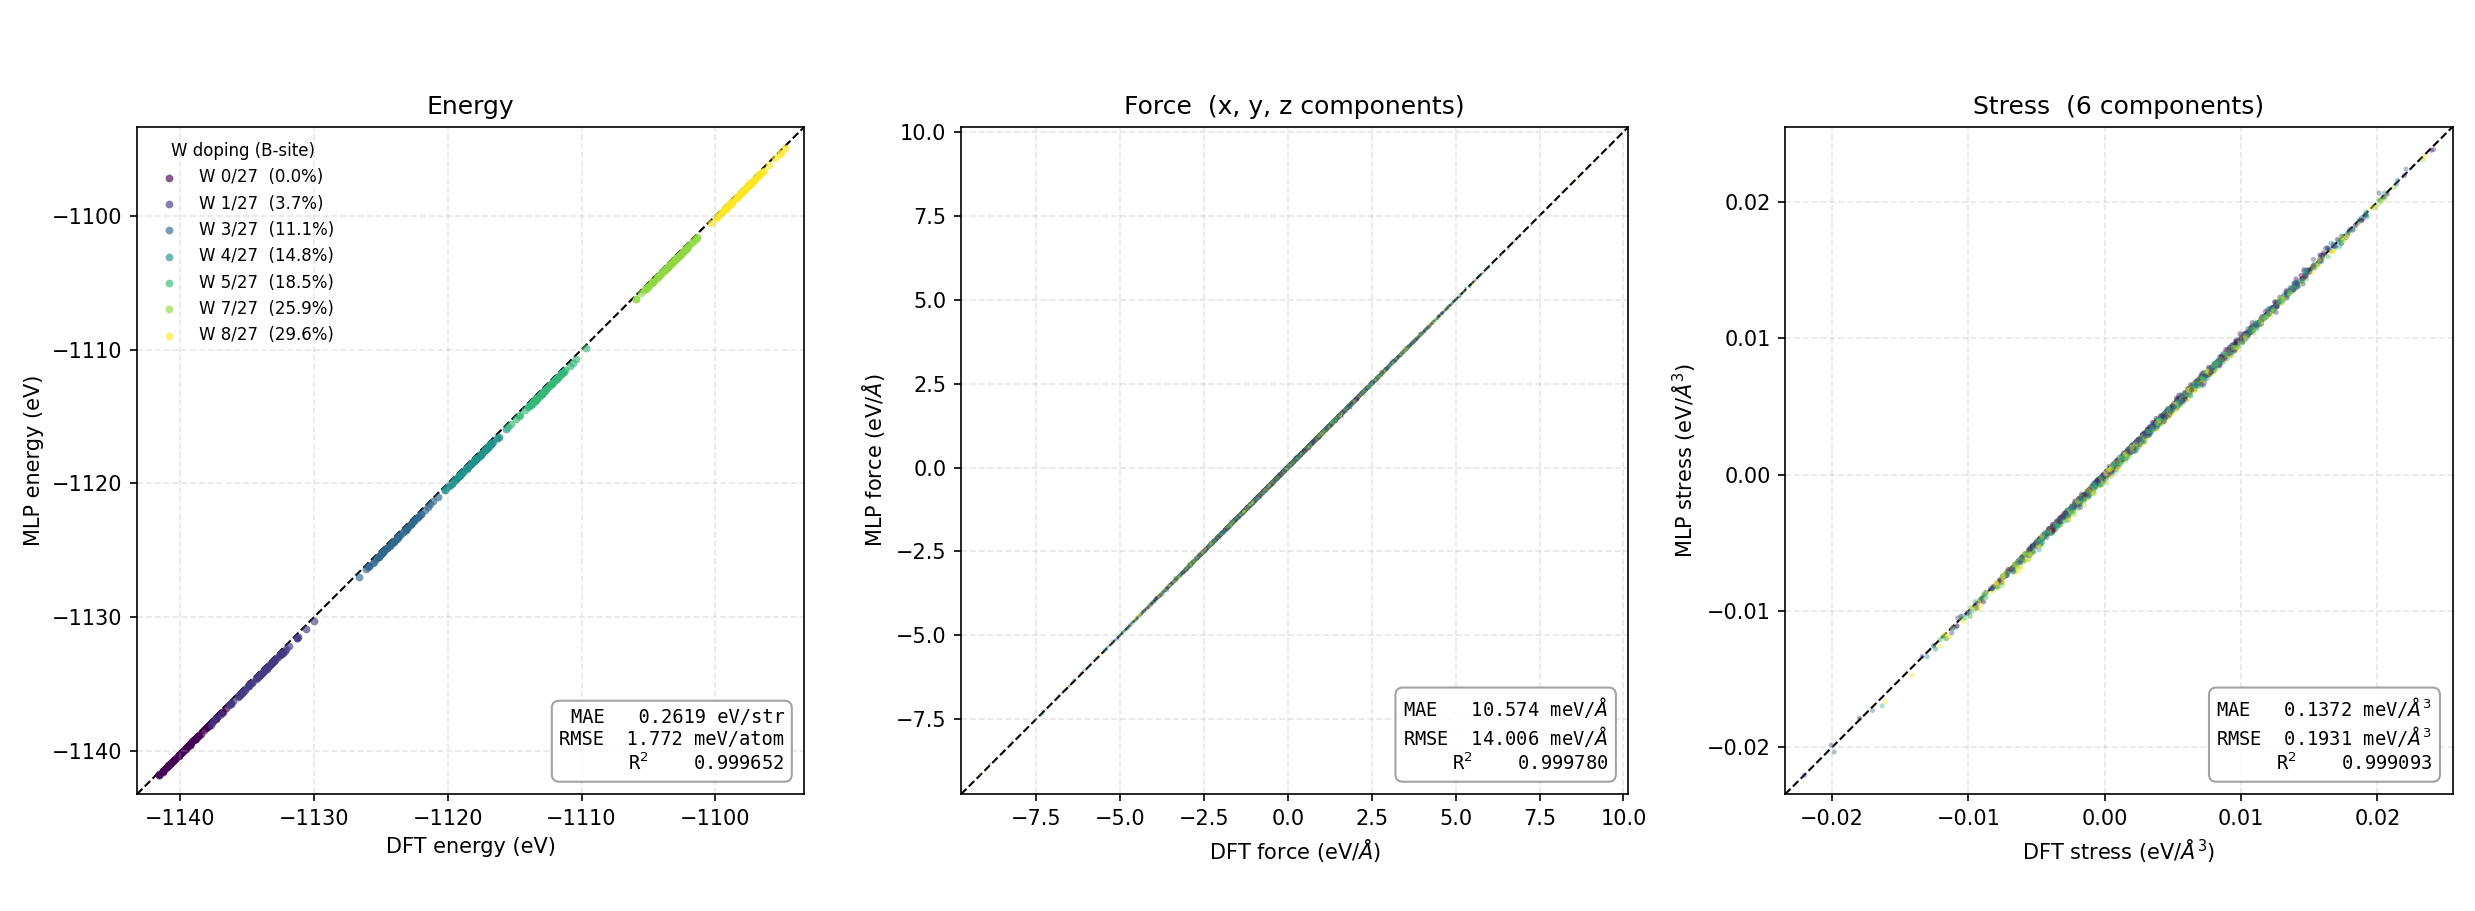

- Foundation model: BAM-core
- Training Dataset: AIMD trajectories of BSW (3,800 frames)
- Training epochs: 26
- Test set errors
  - Energy_RMSE = 1.772 meV/atom
  -  Force_RMSE =  14.006 meV/Å
  - Stress_RMSE = 0.1931 meV/Å<sup>3</sup>


###Target system 정보

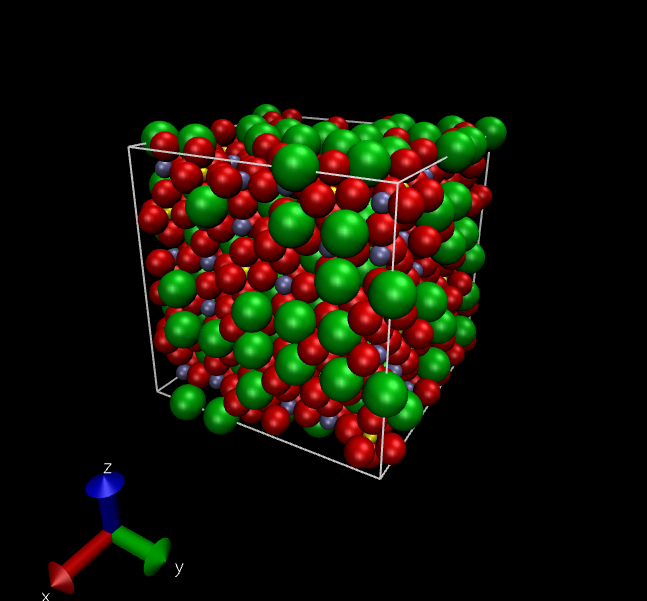

- Material: BaSc<sub>0.7</sub>W<sub>0.3</sub>O<sub>3</sub>H<sub>0.1</sub>
- Supercell size: 6x6x6

- Number of Atoms

  - Ba 216
  - H 24
  - O 648
  - Sc 152
  - W 64

  Total = 1104

### LAMMPS input 설정 (in.lammps)


In [ ]:
# W-doped BaScO3 proton conductor — RACE MLIP MD (fresh: equilibration + production)
units           metal
newton          on
atom_style      atomic
atom_modify     map yes

read_data       W_doped_BaSc_Structure
timestep        0.0005        # Systems containing H require a small timestep (<= 0.5 fs)

# machine-learning interatomic potential
pair_style      mliap unified ./model-lammps.pt 0       # set mliap option and loat fine-tuned model
pair_coeff      * * Ba H O Sc W

group           h type 2        # select the H atoms to be tracked for the proton MSD
fix             nodrift all momentum 100 linear 1 1 1

# MSD calculation setting
variable time equal step*dt
compute msd_h h msd com no

fix msd_output all print 100 "${time} $(c_msd_h[4])" &
  file msd_output.dat screen no title "# Time(ps) MSD_H" append msd_output.dat

# initialize velocities at target temperature (from 0 K optimized structure)
velocity        all create 673.0 4003 dist gaussian mom yes rot yes

# 1) NVT equilibration — 20 ps
thermo          200
thermo_style    custom step temp pe ke etotal press vol
fix             eq_nvt all nvt temp 673.0 673.0 0.05
run             40000
unfix           eq_nvt

# 2) NPT equilibration (cell/volume relaxation) — 50 ps
fix             eq_npt all npt temp 673.0 673.0 0.05 iso 1.0 1.0 0.5
run             100000
unfix           eq_npt

# 3) NPT production — 150 ps
reset_timestep  0
dump            traj all custom 200 dump.lammpstrj id type element x y z vx vy vz fx fy fz
dump_modify     traj element Ba H O Sc W format float %.12g flush yes
thermo          200
thermo_style    custom step temp pe ke etotal press vol
fix             prod all npt temp 673.0 673.0 0.05 iso 1.0 1.0 0.5
run             300000 upto       # totally 150ps production


**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `units metal` | 에너지 eV, 거리 Å, 시간 ps. `timestep` 값과 출력 시간축이 모두 ps 단위가 됩니다. |
| `atom_modify map yes` | MLIAP처럼 원자 ID로 접근하는 pair style에 필요한 전역 ID 맵을 생성합니다.
| `read_data` | 초기 구조. atom type 1–5가 아래 `pair_coeff`의 원소 순서와 대응됩니다. |
| `timestep 0.0005` | 0.5 fs. H의 O–H stretching(주기 ~10 fs)을 적분하려면 이보다 크면 안 됩니다. |
| `pair_style mliap unified ./model-lammps.pt 0` | Fine-tuning된 MLIP를 unified 인터페이스로 불러옵니다. 마지막 0은 ghost neighbor 사용 여부 플래그입니다. |
| `pair_coeff * * Ba H O Sc W` | atom type → 원소 매핑. 이 순서 때문에 `H = type 2`가 되며, 이후 모든 분석 스크립트의 H_TYPE = 2가 여기서 결정됩니다.|
| `group h type 2` | MSD를 추적할 proton 그룹.|
| `fix nodrift all momentum 100 linear 1 1 1` | 100 스텝마다 계 전체의 선운동량을 0으로 만들어 전체 드리프트를 제거합니다. |
| `compute msd_h h msd com no` | H 그룹의 MSD. `com no` 이므로 H 그룹의 질량중심을 빼지 않습니다. COM을 빼면 집단적 proton 변위(= 전하를 나르는 성분)까지 지워지므로 `no`가 맞습니다. |
| `c_msd_h[4]` | MSD의 4번째 성분 = x, y, z 합계(전체 MSD). 1–3은 각 축 성분입니다. |
| `fix msd_output all print 100` | 0.05 ps마다 `msd_output.dat`에 기록. `append`라 파일이 있으면 이어 씁니다. |
| `velocity all create 673.0 4003` | 673 K(400 °C)에서 Maxwell 분포로 초기 속도 부여. `4003`은 난수 시드로, 독립 시행을 만들 때 이 값을 바꿉니다.|
| `temp 673.0 673.0 0.05` | 목표 온도와 Tdamp = 0.05 ps (= 100 × timestep). LAMMPS 권장값입니다. |
| `iso 1.0 1.0 0.5` | 등방 압력 1 bar, Pdamp = 0.5 ps (= 1000 × timestep). NPT에서 셀 부피가 이완되므로 전도도 계산 시 초기 부피가 아닌 평균 부피를 써야 합니다.. |
| `reset_timestep 0` | production 구간의 시간축을 0부터 다시 셉니다. |
| `dump traj all custom 200` | 0.1 ps마다 궤적 저장. 이 값이 분석 스크립트의 프레임 간격(`frame_ps = 200 × 0.0005`)입니다. |
| `dump_modify traj element Ba H O Sc W` | dump에 원소 기호 컬럼을 추가합니다. ASE로 읽을 때 필요합니다. |
| `run 300000 upto` | `reset_timestep 0` 이후이므로 300,000 스텝 = 150 ps production. |



**Outputs**

- `log.lammps` : `thermo_style`로 지정한 열역학 정보가 200 스텝(0.1 ps)마다 기록됩니다. step, temp, pe, ke, etotal, press, vol 순이며, 온도가 목표값 주변에서 안정적으로 요동하는지, NPT 구간에서 부피(vol)가 수렴했는지를 확인하는 데 씁니다.
- `dump.lammpstrj` 200 스텝(0.1 ps)마다 저장되는 production 궤적입니다. 각 프레임마다 전체 원자의 id, type, element, 좌표(x y z), 속도(vx vy vz), 힘(fx fy fz)과 함께 BOX BOUNDS가 기록됩니다. 좌표는 wrapped 상태이므로 분석 시 minimum image로 unwrap해야 하며, MSD 재계산·proton pathway 시각화·NPT 평균 부피 계산이 모두 이 파일에서 나옵니다.
- `msd_output.dat` : LAMMPS 내장 `compute msd`가 100 스텝(0.05 ps)마다 기록한 H 그룹의 MSD입니다. 시간(ps)과 MSD(Å²) 두 열로 구성되며, single-time origin 방식이라 뒤에서 다룰 MTO 결과와 비교하는 기준이 됩니다.


###MD Trajectory 결과 분석 예시

#### 1) Proton MSD 가공 및 Proton Diffusivity 계산

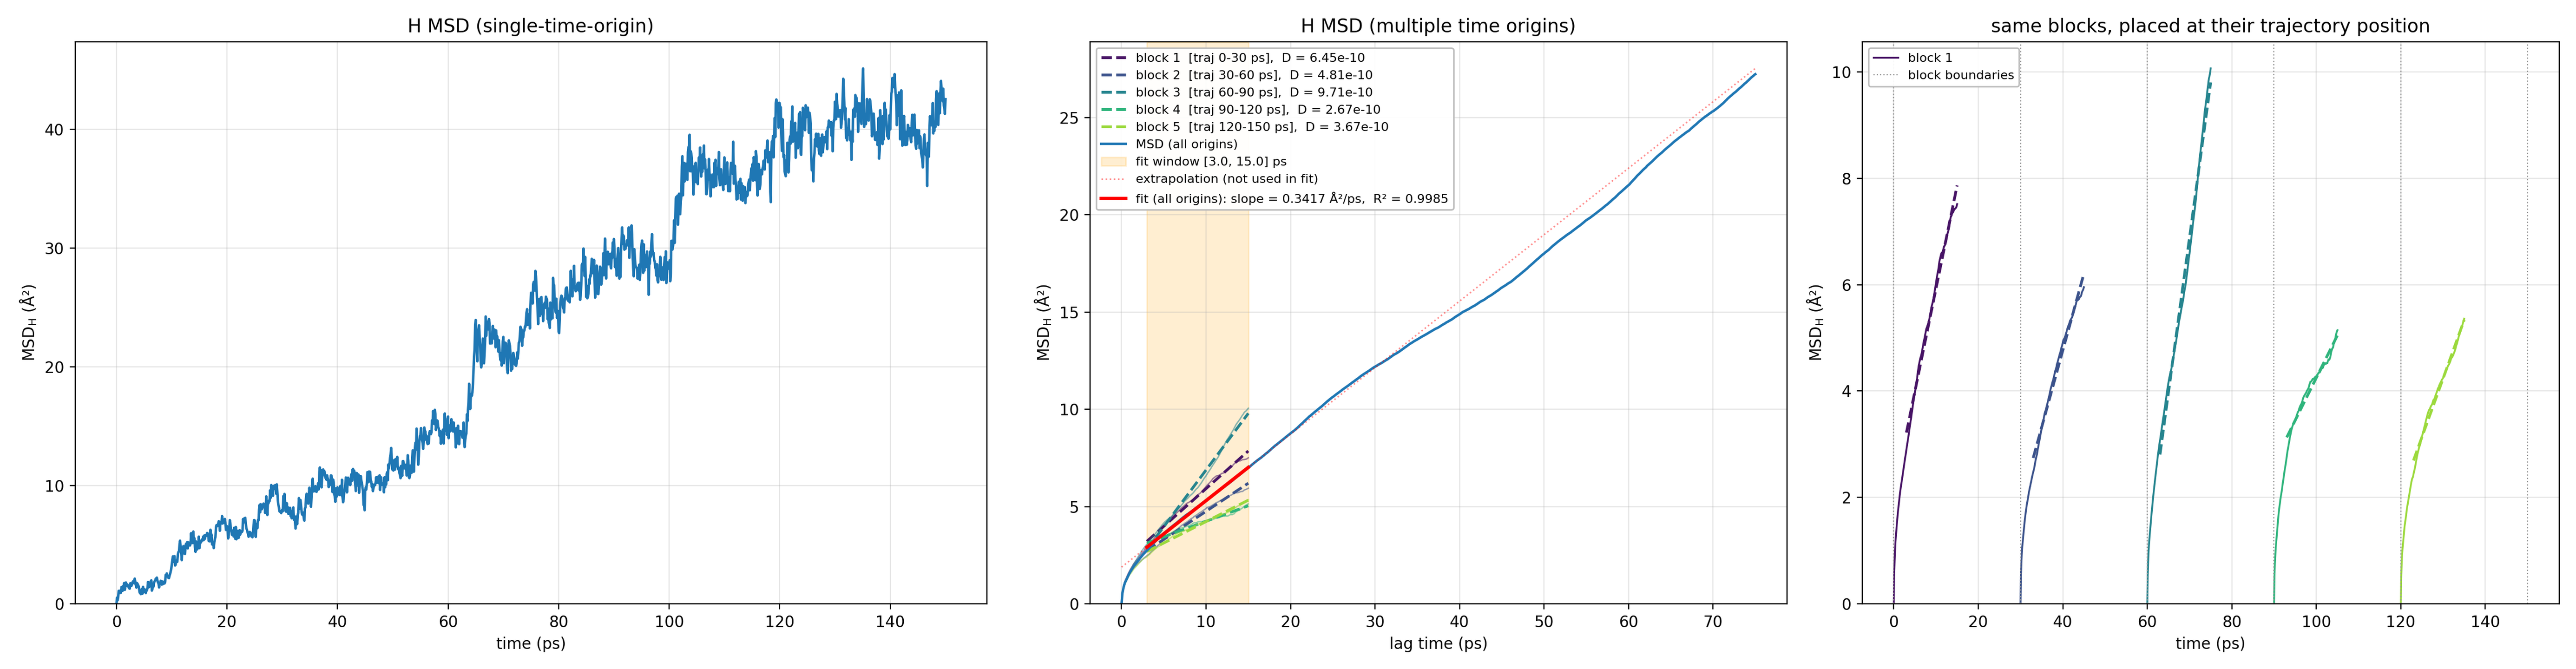

- MLMD production이 끝나면 LAMMPS 내장 기능으로 `msd_output.dat`이 생성됨

- 이 파일은 single-time origin(STO) 방식으로 계산된 것으로, 왼쪽 패널과 같은 형태

- STO는 기준 프레임이 하나뿐이라 lag가 길어질수록 통계가 부족해 노이즈가 큼

  -> 초기 구조에 조금씩 다른 distortion을 주어 독립적인 MD를 N회 수행하고 평균하는 것이 정석

- 연구 과정에서 diffusivity를 빠르게 확인하려면 같은 궤적을 multi-time origin(MTO)으로 다시 계산한 뒤 block averaging을 적용

  -> 가운데 패널: 단일 궤적만으로도 어느 정도 신뢰할 만한 기울기와 오차 범위 확보

  -> 오른쪽 패널: 각 block이 궤적의 어느 구간에서 나온 것인지 확인 가능

- 단, MTO의 origin들은 서로 완전히 독립적이지 않으므로 오차가 실제보다 작게 평가될 수 있음

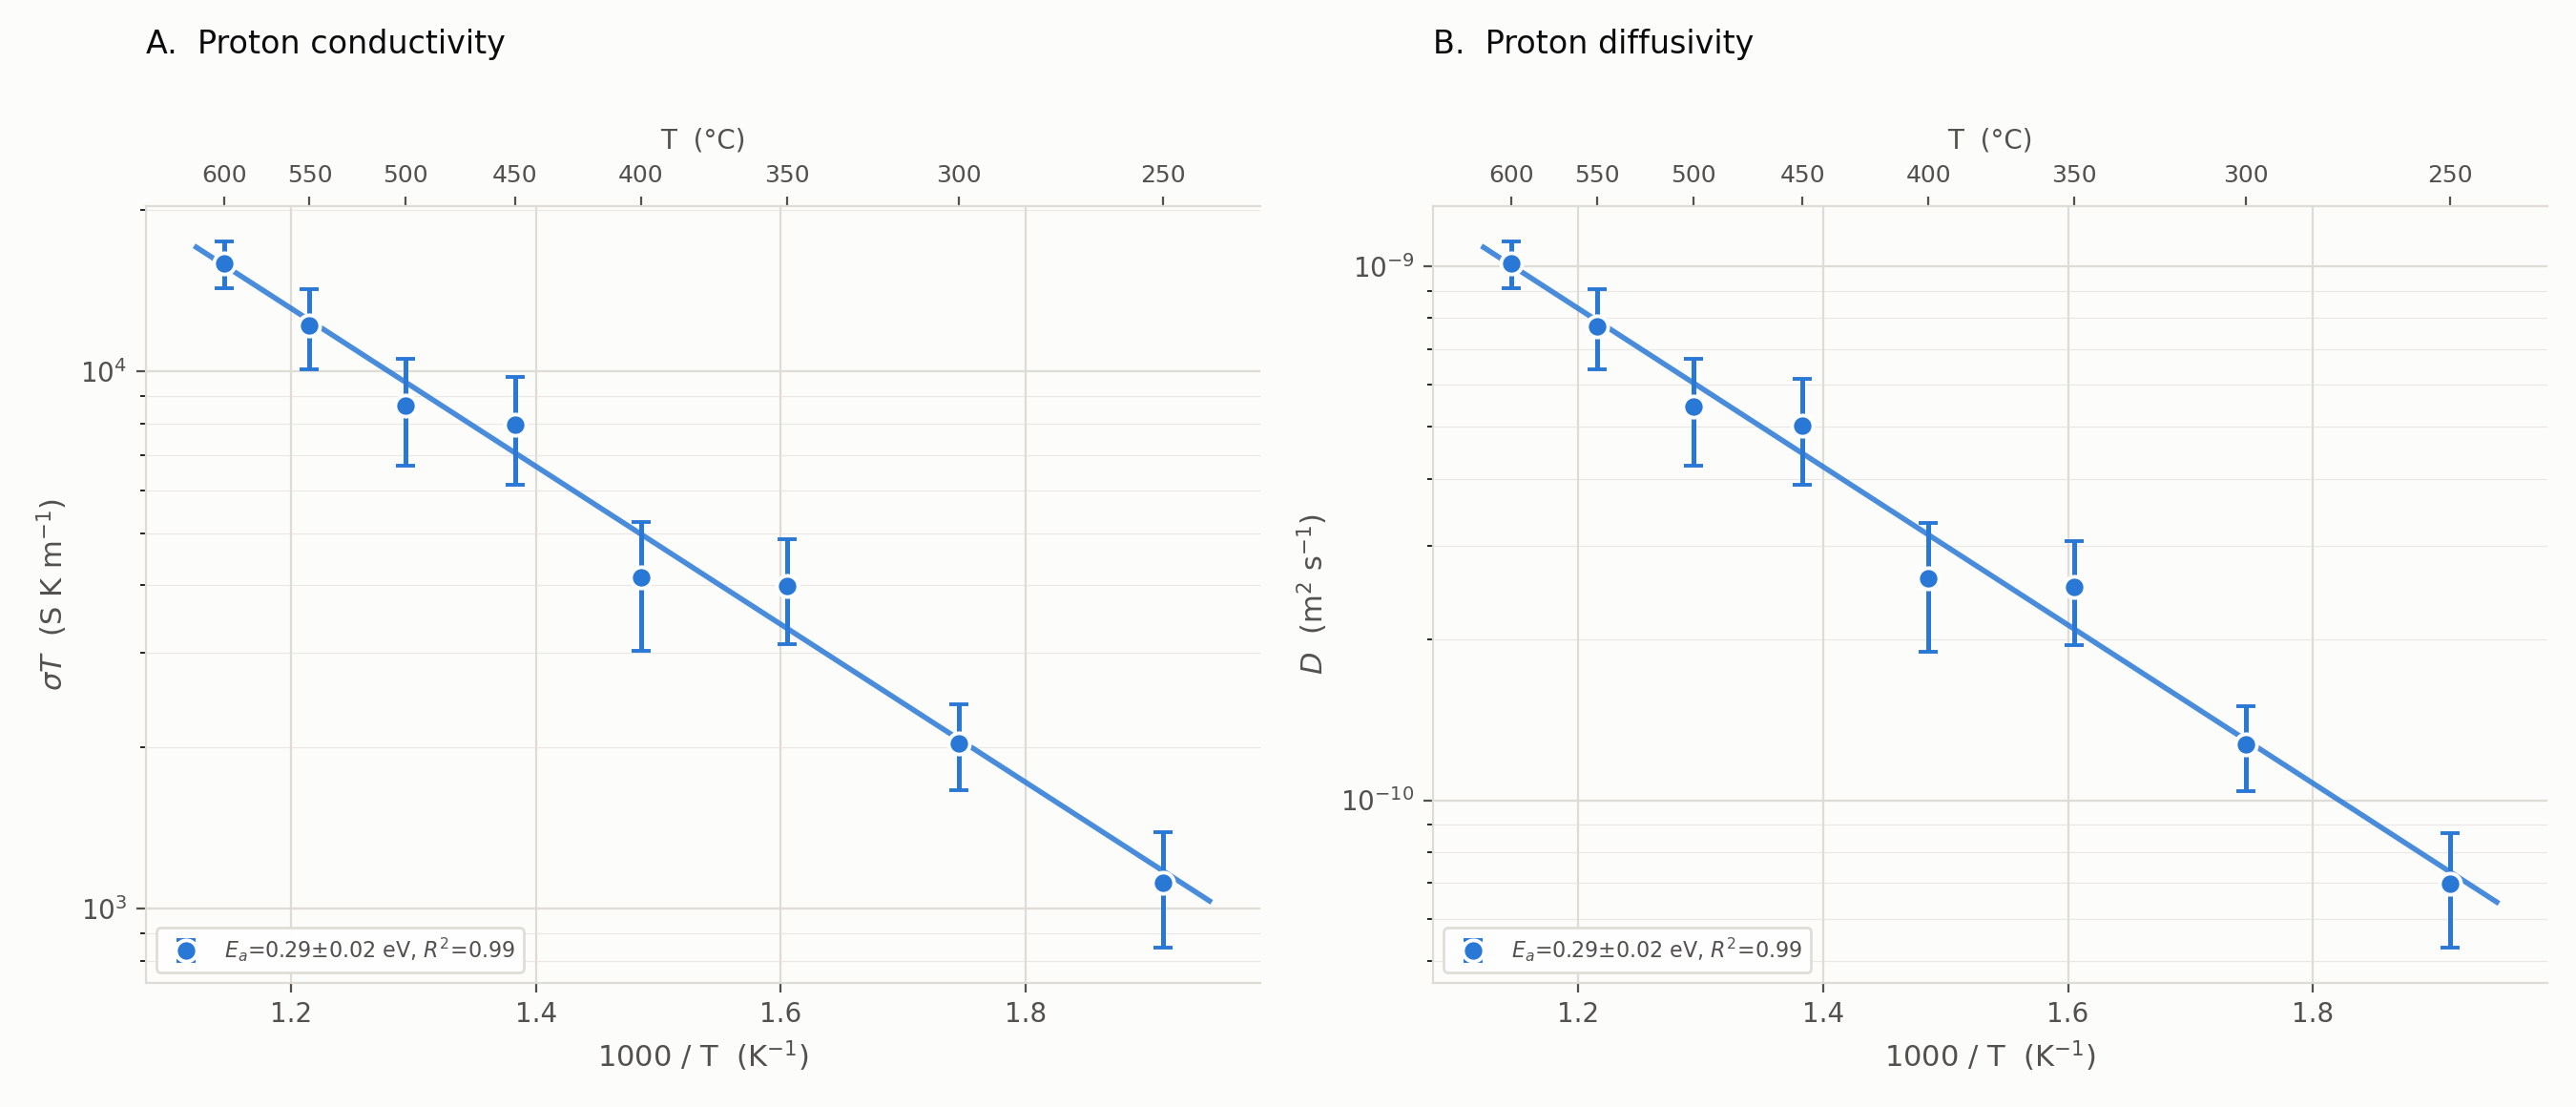

- 여러 온도에서 같은 과정을 반복하여 proton diffusivity를 얻고, Nernst-Einstein 관계를 통해 proton conductivity로 변환

- 이렇게 얻은 값으로 Arrhenius plot을 그려 활성화 에너지 산출 가능

  -> ln D vs 1/T의 기울기 = -Eₐ/k_B

#### Atomic scale에서의 거동 분석

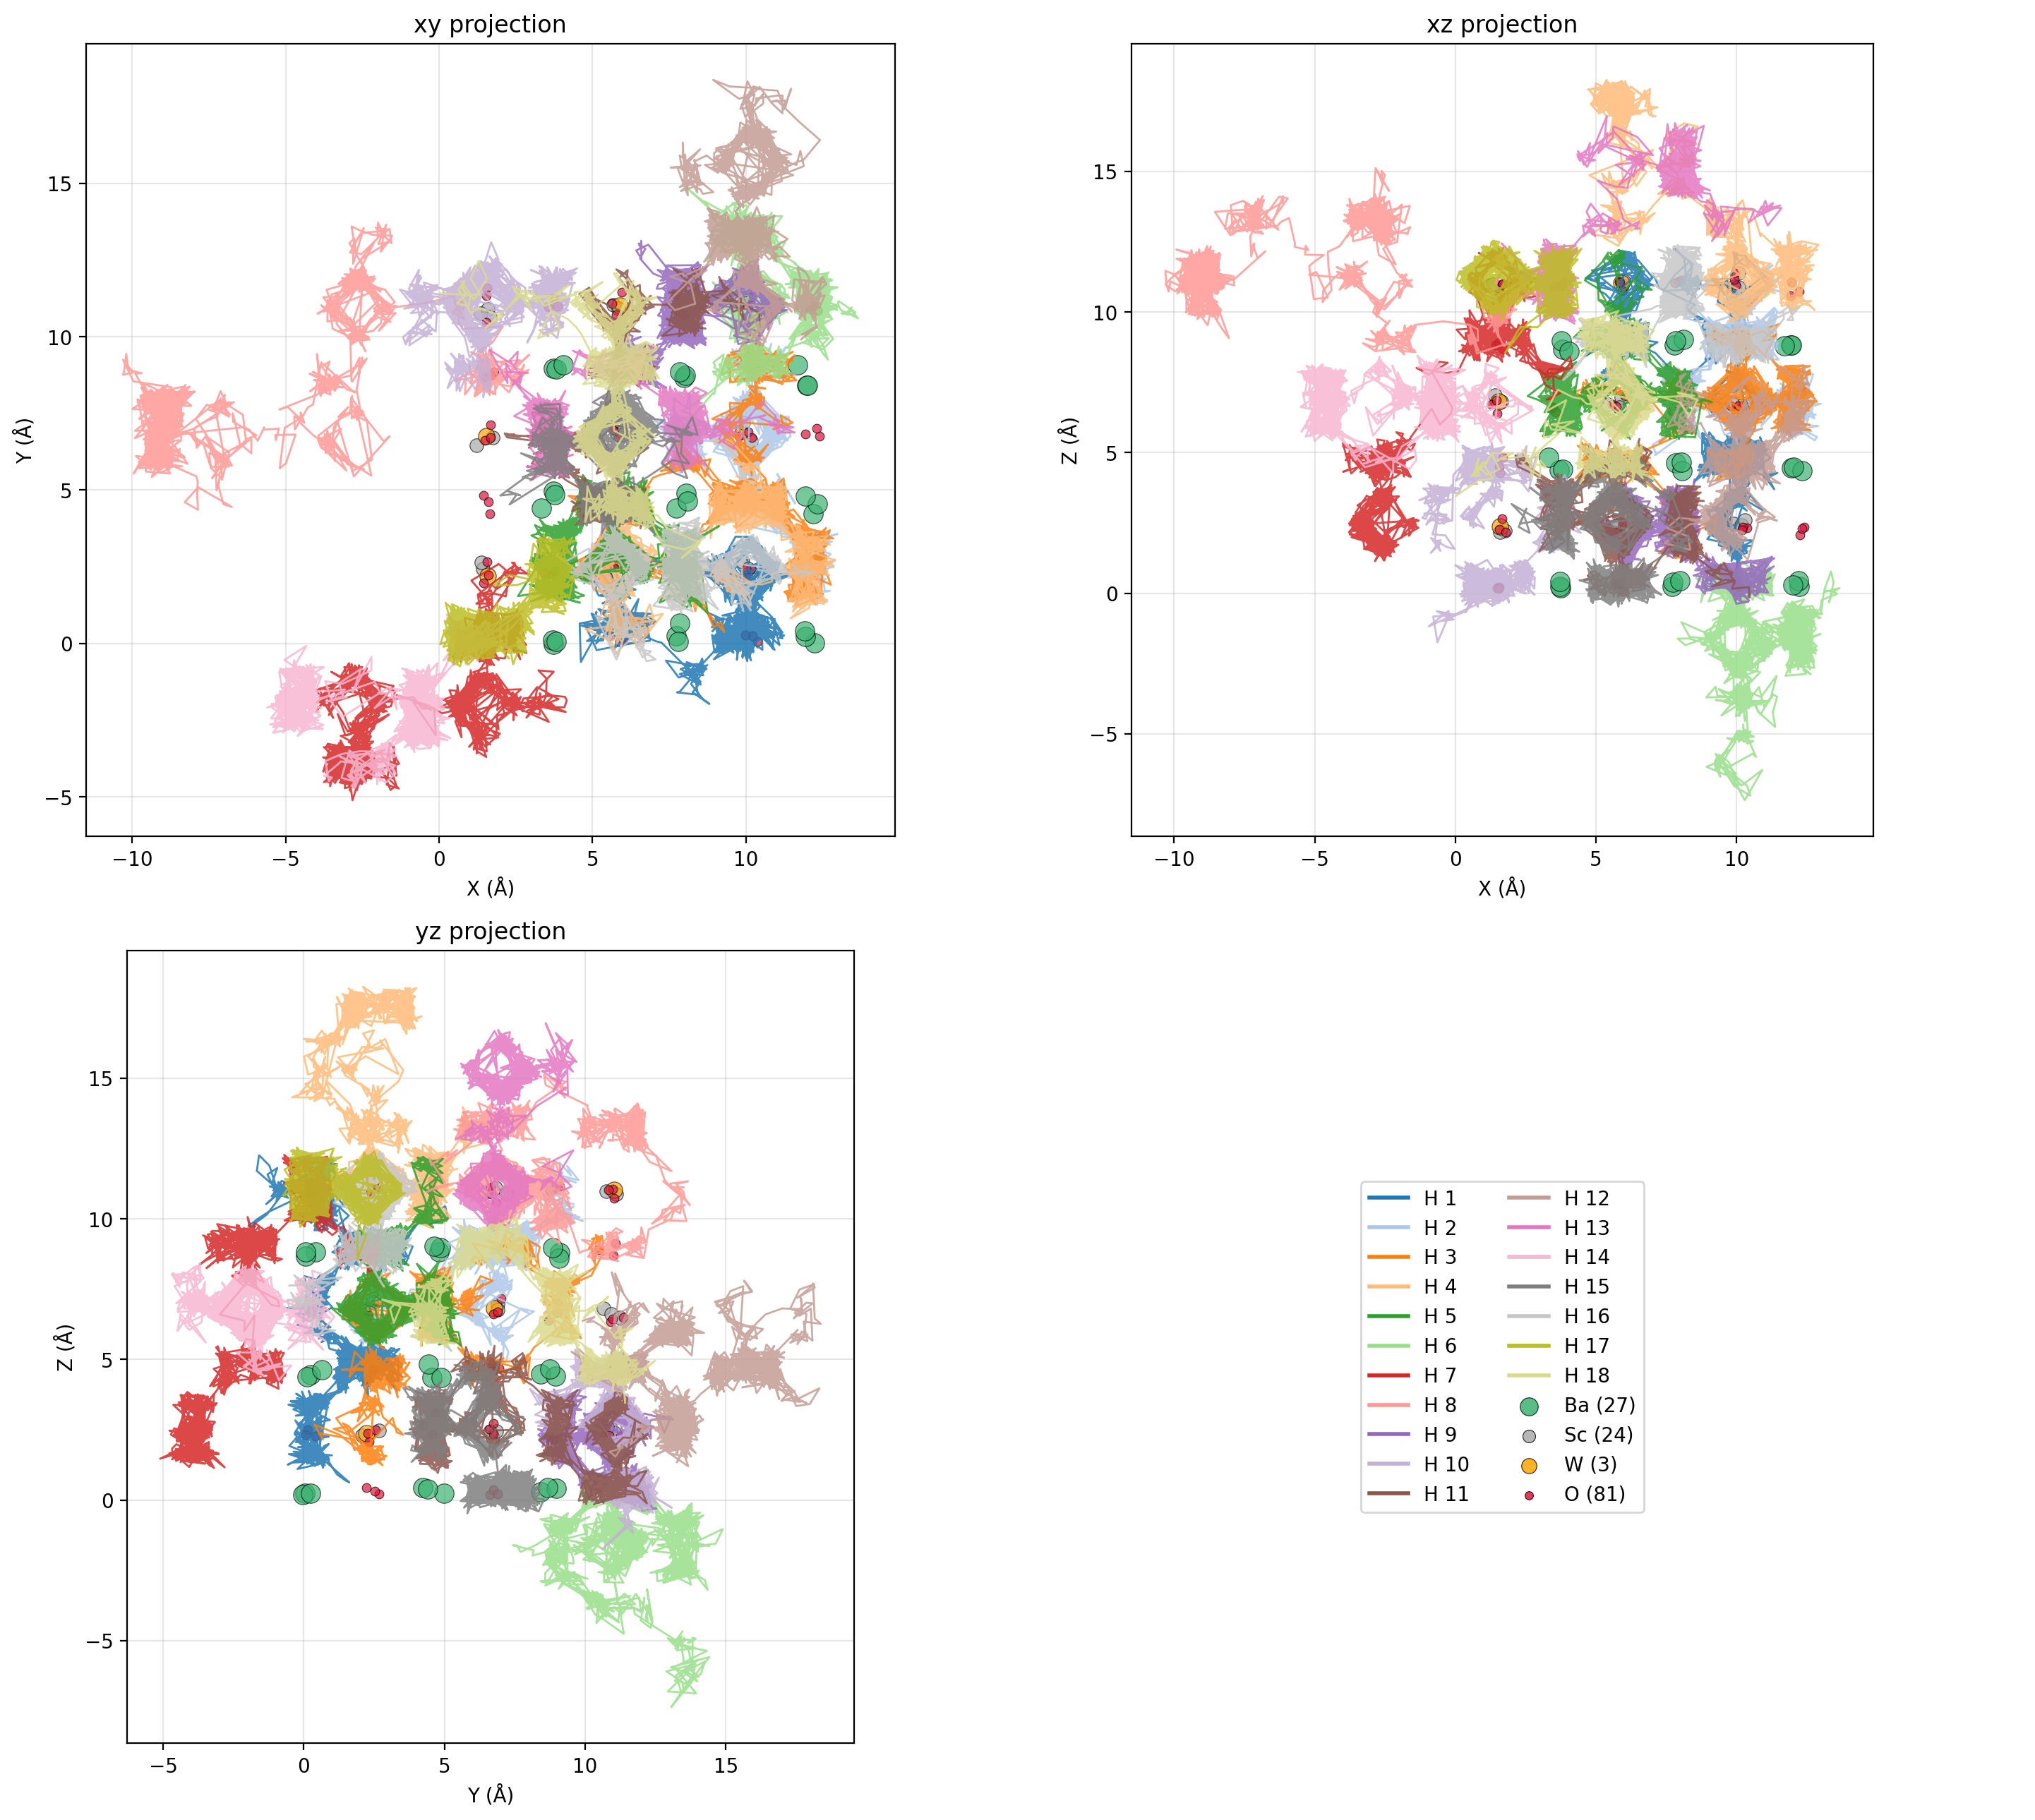

- Trajectory 속 proton pathway를 시각화하여 atomic scale에서 메커니즘 분석 가능

- 본 MLMD 결과에서 관찰된 현상

  -> Sc(3+) 주변에서의 proton trapping

  -> W(6+) 도핑 농도가 높아질수록 proton pathway가 제한됨

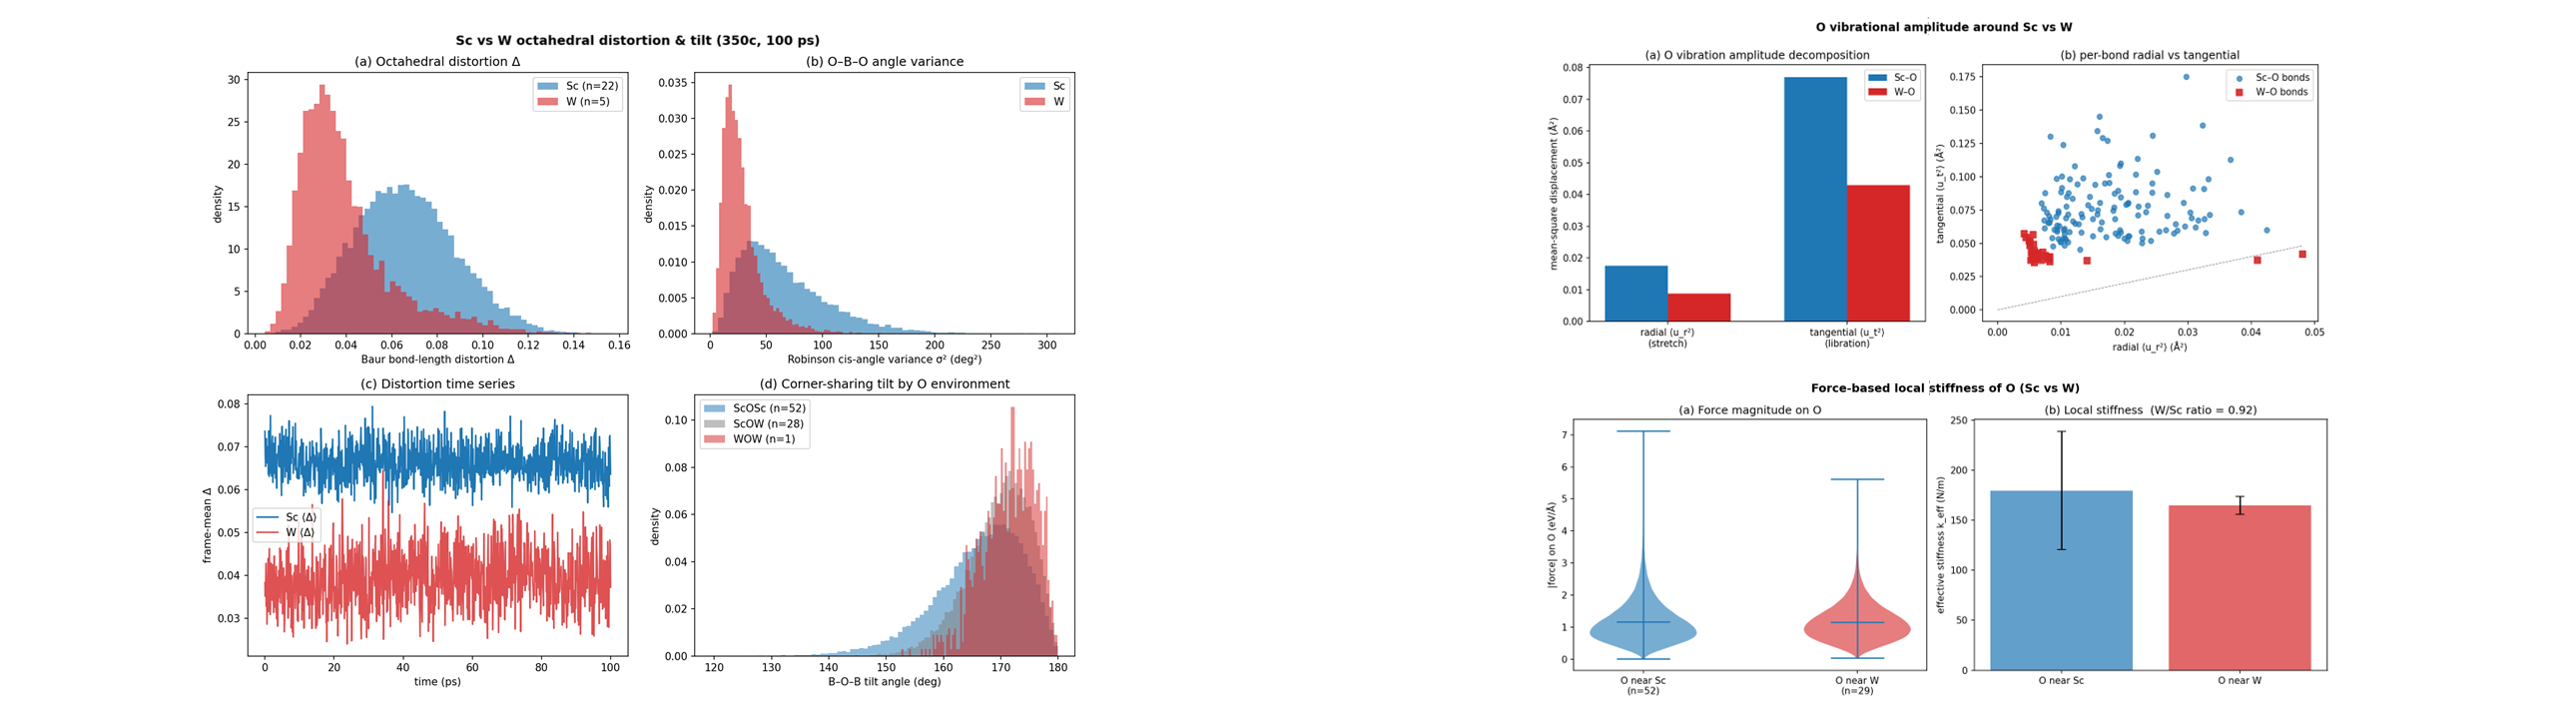

- B-site 원소를 중심으로 octahedron을 이루는 oxygen의 거동을 분석

- Sc 중심보다 W 중심 octahedron이 구조적으로 더 안정함을 atomic scale에서 확인

  -> Baur distortion index, Robinson angle variance, B-O-B tilt angle, O의 진동 진폭(radial/tangential), 힘 기반 유효 강성 등을 분석